# Phase 05E - BTUMQA-225K Modern Medical VLM Baseline Comparison

This notebook is intentionally dependency-light. Run it after any Phase 05D modern VLM baseline has written prediction CSVs to Drive.

Available prediction files are loaded dynamically. Missing optional baselines such as LLaVA-Med and MedGemma are recorded in the availability report and skipped from all result tables, figures, and statistical analyses.


## Dual Environment Compatibility Setup & Install Required Libraries


In [1]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

import subprocess
import sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"],
    check=True,
)
print("Required libraries are installed.")


Required libraries are installed.


## Mount Drive and Configure Paths


In [2]:
from google.colab import drive
from pathlib import Path
import os
import time


def ensure_drive_connection(project_dir: Path, mount_point: str = "/content/drive"):
    def probe_path(target: Path):
        probe_target = target if target.exists() else target.parent
        return os.listdir(str(probe_target))

    try:
        probe_path(project_dir)
    except OSError as exc:
        if getattr(exc, "errno", None) != 107:
            raise
        print("Detected a stale Google Drive mount. Remounting now...")
        try:
            drive.flush_and_unmount()
            time.sleep(2)
        except Exception:
            pass
#         drive.mount(mount_point, force_remount=True)
        time.sleep(2)
        probe_path(project_dir)

    if not project_dir.exists():
        raise FileNotFoundError(
            f"Project Drive directory not found after mount check: {project_dir}"
        )


# drive.mount("/content/drive")

# Updated project path to point to the new drive structure
PROJECT_DRIVE_DIR = PROJECT_ROOT
ensure_drive_connection(PROJECT_DRIVE_DIR)

# Fallback-aware base directory for Phase 5D predictions
PHASE5D_BASE_DIR = PROJECT_DRIVE_DIR / "phase_5" / "p5d_modern_baseline_comparison_models"
if not PHASE5D_BASE_DIR.exists():
    PHASE5D_BASE_DIR = PROJECT_DRIVE_DIR / "phase_5" / "p5d_modern_vlm"
if not PHASE5D_BASE_DIR.exists():
    PHASE5D_BASE_DIR = PROJECT_DRIVE_DIR / "phase_5d_modern_vlm"

LLAVA_DIR = PHASE5D_BASE_DIR / "llava_med" / "btumqa_225k_llava_med_zero_shot"
BIOMEDCLIP_DIR = PHASE5D_BASE_DIR / "biomed_clip" / "btumqa_225k_biomedclip_frozen_matching"
BIOMEDCLIP_MASK_OVERLAY_DIR = PHASE5D_BASE_DIR / "biomed_clip_mask_overlay" / "btumqa_225k_biomedclip_monai_mask_overlay"
MEDGEMMA_DIR = PHASE5D_BASE_DIR / "medgemma" / "btumqa_225k_medgemma_4b_it_zero_shot"

# Corrected paths: phase_5/p5e_modern_vlm_baseline_comparison
PHASE5E_DIR = (
    PROJECT_DRIVE_DIR
    / "phase_5"
    / "p5e_modern_vlm_baseline_comparison"
    / "btumqa_225k_modern_vlm_comparison"
)
TABLES_DIR = PHASE5E_DIR / "tables"
FIGURES_DIR = PHASE5E_DIR / "figures"
REPORTS_DIR = PHASE5E_DIR / "reports"
DONE_DIR = PHASE5E_DIR / "done"
for path in [PHASE5E_DIR, TABLES_DIR, FIGURES_DIR, REPORTS_DIR, DONE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Corrected candidate lists pointing to phase_3 and phase_5
DATASET_CSV_CANDIDATES = [
    PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k",
    PROJECT_DRIVE_DIR / "Dataset" / "dataset_btumqa_225k",
    PROJECT_DRIVE_DIR / "dataset_btumqa_225k",
]
PHASE5B_CANDIDATES = [
    PROJECT_DRIVE_DIR / "phase_5" / "p5b_final_evaluation_ablation_calibration" / "btumqa_225k_clean_metadata_four_seeds_final_comparison",
    PROJECT_DRIVE_DIR / "phase_5" / "p5b_final_evaluation_ablation_calibration" / "btumqa_225k_four_seeds_final_comparison",
    PROJECT_DRIVE_DIR / "phase_5b_final_evaluation_ablation_calibration" / "btumqa_225k_four_seeds_final_comparison",
]


def first_existing_dir(candidates, name):
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {name}. Checked:\n"
        + "\n".join(str(path) for path in candidates)
    )


DATASET_DIR = first_existing_dir(DATASET_CSV_CANDIDATES, "BTUMQA-225K dataset directory")
PHASE5B_DIR = first_existing_dir(PHASE5B_CANDIDATES, "Phase 05B four-seed result directory")
TEST_CSV_PATH = DATASET_DIR / "btumqa_225k_test.csv"
PHASE5B_TABLES_DIR = PHASE5B_DIR / "tables"
PHASE5B_PREDICTIONS_DIR = PHASE5B_DIR / "predictions"

print("Project directory:", PROJECT_DRIVE_DIR)
print("LLaVA-Med result dir:", LLAVA_DIR)
print("BiomedCLIP result dir:", BIOMEDCLIP_DIR)
print("BiomedCLIP mask-overlay result dir:", BIOMEDCLIP_MASK_OVERLAY_DIR)
print("MedGemma result dir:", MEDGEMMA_DIR)
print("Phase 05B dir:", PHASE5B_DIR)
print("Phase 05E output dir:", PHASE5E_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
LLaVA-Med result dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/llava_med/btumqa_225k_llava_med_zero_shot
BiomedCLIP result dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/biomed_clip/btumqa_225k_biomedclip_frozen_matching
BiomedCLIP mask-overlay result dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/biomed_clip_mask_overlay/btumqa_225k_biomedclip_monai_mask_overlay
MedGemma result dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/medgemma/btumqa_225k_medgemma_4b_it_zero_shot
Phase 05B dir: /content/drive/MyDrive/AMIR Lab/Research A

## Configuration and Helpers


In [3]:
import json
import math
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, log_loss

sns.set_theme(style="whitegrid", context="talk", font_scale=0.82)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#d6dde5",
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

RANDOM_STATE = 42
RUN_MODE = "full"  # Use "pilot" for a quick check, then "full" for paper tables.
BOOTSTRAP_ITERATIONS = 2000  # Use 2000 for final paper-quality CIs if time permits.
CALIBRATION_BINS = 15
SELECTIVE_COVERAGES = [0.50, 0.70, 0.80, 0.90, 0.95, 1.00]
CONFIDENCE_EPS = 1e-8
MIN_SLICE_ROWS = 25

MODEL_LABELS = {
    "llava_med": "LLaVA-Med",
    "biomedclip": "BiomedCLIP",
    "biomedclip_mask_overlay": "BiomedCLIP + MONAI Mask Overlay",
    "medgemma_4b_it": "MedGemma 4B-IT",
    "prugtm_hybrid_qcur": "PRUGTM-Hybrid + Q-CUR",
}
MODEL_ORDER = [
    "prugtm_hybrid_qcur",
    "biomedclip",
    "biomedclip_mask_overlay",
    "llava_med",
    "medgemma_4b_it",
]
MODEL_PALETTE = {
    "PRUGTM-Hybrid + Q-CUR": "#247a69",
    "BiomedCLIP": "#2f6f9f",
    "BiomedCLIP + MONAI Mask Overlay": "#8a5a44",
    "LLaVA-Med": "#8d6ab8",
    "MedGemma 4B-IT": "#c98936",
}
METRIC_DIRECTIONS = {
    "accuracy": "higher",
    "macro_f1": "higher",
    "weighted_f1": "higher",
    "ece": "lower",
    "brier": "lower",
    "nll": "lower",
    "aurc": "lower",
}

KEY_SLICE_SPEC = [
    ("question_style", "comparative"),
    ("question_family", "more_reliable_region"),
    ("question_family", "more_uncertain_region"),
    ("ambiguity_flag", "yes"),
    ("signal_gap_bucket", "close_gap"),
    ("signal_gap_bucket", "moderate_gap"),
    ("signal_gap_bucket", "wide_gap"),
]


def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def write_json(path: Path, payload: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def save_dataframe(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")


def prediction_filename():
    return f"{RUN_MODE}_predictions.csv" if RUN_MODE == "pilot" else "test_predictions.csv"


def clamp_probs(values, eps=CONFIDENCE_EPS):
    arr = np.asarray(values, dtype=np.float64)
    return np.clip(arr, eps, 1.0 - eps)


def ordered_model_labels(model_keys):
    ordered = [key for key in MODEL_ORDER if key in model_keys]
    ordered.extend([key for key in model_keys if key not in ordered])
    return [MODEL_LABELS.get(key, key) for key in ordered]


def model_sort_key(model_key):
    return MODEL_ORDER.index(model_key) if model_key in MODEL_ORDER else len(MODEL_ORDER)


def compute_answer_metrics(df: pd.DataFrame):
    valid_df = df.copy()
    if "answer_parse_status" in valid_df.columns:
        error_mask = valid_df["answer_parse_status"].astype(str).str.lower().isin(["error", "missing", ""])
    else:
        error_mask = valid_df["predicted_answer"].isna() | (valid_df["predicted_answer"].astype(str).str.len() == 0)
    valid_df = valid_df.loc[~error_mask].copy()
    if len(valid_df) == 0:
        return {
            "n": int(len(df)),
            "valid_n": 0,
            "error_n": int(error_mask.sum()),
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
        }
    return {
        "n": int(len(df)),
        "valid_n": int(len(valid_df)),
        "error_n": int(error_mask.sum()),
        "accuracy": float(accuracy_score(valid_df["gold_answer"], valid_df["predicted_answer"])),
        "macro_f1": float(f1_score(valid_df["gold_answer"], valid_df["predicted_answer"], average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(valid_df["gold_answer"], valid_df["predicted_answer"], average="weighted", zero_division=0)),
    }


def compute_ece(y_true, y_prob):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_prob = clamp_probs(y_prob)
    bin_edges = np.linspace(0.0, 1.0, CALIBRATION_BINS + 1)
    ece = 0.0
    for idx in range(CALIBRATION_BINS):
        left = bin_edges[idx]
        right = bin_edges[idx + 1]
        mask = (y_prob >= left) & (y_prob <= right) if idx == CALIBRATION_BINS - 1 else (y_prob >= left) & (y_prob < right)
        count = int(mask.sum())
        if count == 0:
            continue
        ece += (count / len(y_true)) * abs(float(y_prob[mask].mean()) - float(y_true[mask].mean()))
    return float(ece)


def compute_aurc(y_true, y_prob):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    order = np.argsort(-y_prob)
    correct_sorted = y_true[order]
    cumulative_correct = np.cumsum(correct_sorted)
    counts = np.arange(1, len(correct_sorted) + 1, dtype=np.float64)
    coverage = counts / len(correct_sorted)
    risk = 1.0 - (cumulative_correct / counts)
    return float(np.trapezoid(risk, coverage))


def compute_calibration_metrics(df: pd.DataFrame):
    usable = df.dropna(subset=["confidence"]).copy()
    usable["confidence"] = usable["confidence"].astype(float)
    usable = usable[(usable["confidence"] >= 0.0) & (usable["confidence"] <= 1.0)]
    if len(usable) == 0:
        return None
    y_true = usable["is_correct"].astype(int).to_numpy()
    y_prob = clamp_probs(usable["confidence"].to_numpy())
    metrics = {
        "calibration_n": int(len(usable)),
        "ece": compute_ece(y_true, y_prob),
        "brier": float(np.mean((y_prob - y_true) ** 2)),
        "nll": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "aurc": compute_aurc(y_true, y_prob),
    }
    for coverage in SELECTIVE_COVERAGES:
        order = np.argsort(-y_prob)
        k = max(1, int(math.ceil(len(y_true) * float(coverage))))
        metrics[f"selective_acc_at_{coverage:.2f}"] = float(y_true[order][:k].mean())
    return metrics


def compute_metric_value(df: pd.DataFrame, metric_name: str):
    if metric_name in {"accuracy", "macro_f1", "weighted_f1"}:
        metrics = compute_answer_metrics(df)
        return float(metrics[metric_name])
    if metric_name in {"ece", "brier", "nll", "aurc"}:
        metrics = compute_calibration_metrics(df)
        if metrics is None:
            return np.nan
        return float(metrics[metric_name])
    raise ValueError(metric_name)


def bootstrap_metric_ci(df: pd.DataFrame, metric_name: str):
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(df)
    values = []
    if n == 0:
        return {
            "metric": metric_name,
            "metric_direction": METRIC_DIRECTIONS.get(metric_name, "higher"),
            "observed": np.nan,
            "bootstrap_mean": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }
    for _ in range(BOOTSTRAP_ITERATIONS):
        idx = rng.integers(0, n, size=n)
        values.append(compute_metric_value(df.iloc[idx], metric_name))
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    observed = compute_metric_value(df, metric_name)
    if len(values) == 0:
        ci_low = np.nan
        ci_high = np.nan
        bootstrap_mean = np.nan
    else:
        ci_low = float(np.percentile(values, 2.5))
        ci_high = float(np.percentile(values, 97.5))
        bootstrap_mean = float(values.mean())
    return {
        "metric": metric_name,
        "metric_direction": METRIC_DIRECTIONS.get(metric_name, "higher"),
        "observed": float(observed) if np.isfinite(observed) else np.nan,
        "bootstrap_mean": bootstrap_mean,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }


def paired_bootstrap_difference(reference_df: pd.DataFrame, baseline_df: pd.DataFrame, metric_name: str):
    ref_cols = ["qa_id", "gold_answer", "predicted_answer"]
    base_cols = ["qa_id", "predicted_answer"]
    if "confidence" in reference_df.columns:
        ref_cols.append("confidence")
    if "confidence" in baseline_df.columns:
        base_cols.append("confidence")
    merged = reference_df[ref_cols].merge(
        baseline_df[base_cols],
        on="qa_id",
        suffixes=("_reference", "_baseline"),
    )
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(merged)
    if n == 0:
        return {
            "metric": metric_name,
            "metric_direction": METRIC_DIRECTIONS.get(metric_name, "higher"),
            "paired_n": 0,
            "reference_observed": np.nan,
            "baseline_observed": np.nan,
            "difference_mean": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "p_two_sided": np.nan,
            "support": "no_overlap",
        }
    diffs = []
    for _ in range(BOOTSTRAP_ITERATIONS):
        idx = rng.integers(0, n, size=n)
        sample = merged.iloc[idx].copy()
        ref_sample = pd.DataFrame(
            {
                "gold_answer": sample["gold_answer"],
                "predicted_answer": sample["predicted_answer_reference"],
            }
        )
        base_sample = pd.DataFrame(
            {
                "gold_answer": sample["gold_answer"],
                "predicted_answer": sample["predicted_answer_baseline"],
            }
        )
        if "confidence_reference" in sample.columns:
            ref_sample["confidence"] = sample["confidence_reference"]
            ref_sample["is_correct"] = (ref_sample["gold_answer"].astype(str) == ref_sample["predicted_answer"].astype(str)).astype(int)
        if "confidence_baseline" in sample.columns:
            base_sample["confidence"] = sample["confidence_baseline"]
            base_sample["is_correct"] = (base_sample["gold_answer"].astype(str) == base_sample["predicted_answer"].astype(str)).astype(int)
        ref_value = compute_metric_value(ref_sample, metric_name)
        base_value = compute_metric_value(base_sample, metric_name)
        diffs.append(ref_value - base_value)
    diffs = np.asarray(diffs, dtype=np.float64)
    diffs = diffs[np.isfinite(diffs)]
    ref_eval = pd.DataFrame(
        {
            "gold_answer": merged["gold_answer"],
            "predicted_answer": merged["predicted_answer_reference"],
        }
    )
    base_eval = pd.DataFrame(
        {
            "gold_answer": merged["gold_answer"],
            "predicted_answer": merged["predicted_answer_baseline"],
        }
    )
    if "confidence_reference" in merged.columns:
        ref_eval["confidence"] = merged["confidence_reference"]
        ref_eval["is_correct"] = (ref_eval["gold_answer"].astype(str) == ref_eval["predicted_answer"].astype(str)).astype(int)
    if "confidence_baseline" in merged.columns:
        base_eval["confidence"] = merged["confidence_baseline"]
        base_eval["is_correct"] = (base_eval["gold_answer"].astype(str) == base_eval["predicted_answer"].astype(str)).astype(int)
    if len(diffs) == 0:
        diff_mean = ci_low = ci_high = p_two_sided = np.nan
        support = "not_applicable"
    else:
        diff_mean = float(diffs.mean())
        ci_low = float(np.percentile(diffs, 2.5))
        ci_high = float(np.percentile(diffs, 97.5))
        p_two_sided = float(2.0 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)))
        p_two_sided = min(p_two_sided, 1.0)
        support = "positive_ci" if ci_low > 0 else "negative_ci" if ci_high < 0 else "overlaps_zero"
    return {
        "metric": metric_name,
        "metric_direction": METRIC_DIRECTIONS.get(metric_name, "higher"),
        "paired_n": int(n),
        "reference_observed": compute_metric_value(ref_eval, metric_name),
        "baseline_observed": compute_metric_value(base_eval, metric_name),
        "difference_mean": diff_mean,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_two_sided": p_two_sided,
        "support": support,
    }

print("Run mode:", RUN_MODE)


Run mode: full


## Load Modern Baseline Predictions and PRUGTM-Hybrid Reference


In [4]:
test_df = pd.read_csv(TEST_CSV_PATH)
test_df["qa_id"] = test_df["qa_id"].astype(str)
if "answer" in test_df.columns and "gold_answer" not in test_df.columns:
    test_df["gold_answer"] = test_df["answer"].astype(str)
else:
    test_df["gold_answer"] = test_df["gold_answer"].astype(str)

modern_prediction_specs = {
    "llava_med": {
        "path": LLAVA_DIR / "predictions" / prediction_filename(),
        "baseline_family": "generative_medical_vlm",
    },
    "biomedclip": {
        "path": BIOMEDCLIP_DIR / "predictions" / prediction_filename(),
        "baseline_family": "frozen_contrastive_image_text_matching",
    },
    "biomedclip_mask_overlay": {
        "path": BIOMEDCLIP_MASK_OVERLAY_DIR / "predictions" / prediction_filename(),
        "baseline_family": "segmentation_guided_frozen_contrastive_image_text_matching",
    },
    "medgemma_4b_it": {
        "path": MEDGEMMA_DIR / "predictions" / prediction_filename(),
        "baseline_family": "generative_medical_vlm",
    },
}

metadata_cols = [
    "unique_id",
    "question",
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
]
metadata_available = [col for col in metadata_cols if col in test_df.columns]
test_metadata = test_df[["qa_id", "gold_answer"] + metadata_available].drop_duplicates("qa_id")

def normalize_prediction_frame(model_key: str, path: Path, spec: dict):
    df = pd.read_csv(path)
    required = {"qa_id", "gold_answer", "predicted_answer"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{model_key} prediction file missing columns {missing}: {path}")
    df["qa_id"] = df["qa_id"].astype(str)
    df["gold_answer"] = df["gold_answer"].astype(str)
    df["predicted_answer"] = df["predicted_answer"].fillna("").astype(str)
    if "is_correct" not in df.columns:
        df["is_correct"] = (df["gold_answer"] == df["predicted_answer"]).astype(int)
    else:
        df["is_correct"] = pd.to_numeric(df["is_correct"], errors="coerce").fillna(0).astype(int)
    if "confidence" in df.columns:
        df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")
    if "answer_parse_status" not in df.columns:
        df["answer_parse_status"] = np.where(df["predicted_answer"].str.len() > 0, "available", "missing")
    if "baseline_type" not in df.columns:
        df["baseline_type"] = spec["baseline_family"]
    df = df.merge(
        test_metadata.drop(columns=["gold_answer"], errors="ignore"),
        on="qa_id",
        how="left",
        suffixes=("", "_dataset"),
    )
    df["model_key"] = model_key
    df["model_label"] = MODEL_LABELS[model_key]
    return df

modern_predictions = {}
availability_rows = []
for model_key, spec in modern_prediction_specs.items():
    path = spec["path"]
    row = {
        "model_key": model_key,
        "model_label": MODEL_LABELS[model_key],
        "prediction_path": str(path),
        "available": False,
        "loaded_rows": 0,
        "skip_reason": "",
    }
    if not path.exists():
        row["skip_reason"] = "prediction_file_missing"
        availability_rows.append(row)
        print("Prediction file not found, skipping:", MODEL_LABELS[model_key], path)
        continue
    try:
        df = normalize_prediction_frame(model_key, path, spec)
        modern_predictions[model_key] = df
        row["available"] = True
        row["loaded_rows"] = int(len(df))
        print("Loaded", MODEL_LABELS[model_key], len(df), "rows from", path)
    except Exception as exc:
        row["skip_reason"] = f"load_error: {type(exc).__name__}: {exc}"
        print("Could not load prediction file, skipping:", MODEL_LABELS[model_key], exc)
    availability_rows.append(row)

model_availability_df = pd.DataFrame(availability_rows).sort_values("model_key", key=lambda col: col.map(model_sort_key))
availability_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_model_availability.csv"
save_dataframe(model_availability_df, availability_path)
display(model_availability_df)

if not modern_predictions:
    raise RuntimeError(
        "No modern VLM prediction files were loaded. Run at least Phase 05D-B BiomedCLIP "
        "or Phase 05D-D BiomedCLIP mask-overlay first, then rerun Phase 05E."
    )

prugtm_seed_paths = sorted((PHASE5B_PREDICTIONS_DIR / "prugtm_hybrid").glob("seed_*/test_calibrated_predictions.csv"))
if not prugtm_seed_paths:
    raise FileNotFoundError(f"No PRUGTM-Hybrid seed predictions found under {PHASE5B_PREDICTIONS_DIR}")

prugtm_seed_frames = []
for path in prugtm_seed_paths:
    frame = pd.read_csv(path)
    frame["seed"] = path.parent.name
    frame["qa_id"] = frame["qa_id"].astype(str)
    frame["gold_answer"] = frame["gold_answer"].astype(str)
    frame["predicted_answer"] = frame["predicted_answer"].astype(str)
    frame["is_correct"] = frame["is_correct"].astype(int)
    prugtm_seed_frames.append(frame)
    print("Loaded PRUGTM seed:", path.parent.name, len(frame), "rows")
prugtm_all = pd.concat(prugtm_seed_frames, ignore_index=True)

def majority_vote(values):
    counts = Counter(values)
    return counts.most_common(1)[0][0]

reference_rows = []
for qa_id, group in prugtm_all.groupby("qa_id", sort=False):
    first = group.iloc[0]
    predicted = majority_vote(group["predicted_answer"].tolist())
    gold = str(first["gold_answer"])
    row = {
        "qa_id": qa_id,
        "gold_answer": gold,
        "predicted_answer": predicted,
        "is_correct": int(predicted == gold),
        "num_seeds": int(group["seed"].nunique()),
        "seed_correct_mean": float(group["is_correct"].mean()),
    }
    if "qcur_confidence" in group.columns:
        row["confidence"] = float(group["qcur_confidence"].astype(float).mean())
    for col in metadata_cols:
        if col in group.columns:
            row[col] = first[col]
    reference_rows.append(row)
prugtm_reference_df = pd.DataFrame(reference_rows)
if modern_predictions:
    comparison_qa_ids = sorted(
        set().union(*[set(df["qa_id"].astype(str).tolist()) for df in modern_predictions.values()])
    )
    prugtm_eval_df = prugtm_reference_df[
        prugtm_reference_df["qa_id"].astype(str).isin(comparison_qa_ids)
    ].reset_index(drop=True)
else:
    comparison_qa_ids = prugtm_reference_df["qa_id"].astype(str).tolist()
    prugtm_eval_df = prugtm_reference_df.copy().reset_index(drop=True)

print("PRUGTM reference rows:", len(prugtm_reference_df))
print("PRUGTM comparison-scope rows:", len(prugtm_eval_df))
print("Modern baseline prediction files loaded:", list(modern_predictions.keys()))
display(prugtm_eval_df.head())


Prediction file not found, skipping: LLaVA-Med /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/llava_med/btumqa_225k_llava_med_zero_shot/predictions/test_predictions.csv
Loaded BiomedCLIP 33750 rows from /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/biomed_clip/btumqa_225k_biomedclip_frozen_matching/predictions/test_predictions.csv
Loaded BiomedCLIP + MONAI Mask Overlay 33750 rows from /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/biomed_clip_mask_overlay/btumqa_225k_biomedclip_monai_mask_overlay/predictions/test_predictions.csv
Prediction file not found, skipping: MedGemma 4B-IT /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_vlm/medgemma/btumqa_225k_medgemma_4b_it_zero_shot/predictions/test_pr

,model_key,model_label,prediction_path,available,loaded_rows,skip_reason
1,biomedclip,BiomedCLIP,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,33750,
2,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,33750,
0,llava_med,LLaVA-Med,/content/drive/MyDrive/AMIR Lab/Research Assis...,False,0,prediction_file_missing
3,medgemma_4b_it,MedGemma 4B-IT,/content/drive/MyDrive/AMIR Lab/Research Assis...,False,0,prediction_file_missing


Loaded PRUGTM seed: seed_1337 33750 rows
Loaded PRUGTM seed: seed_2025 33750 rows
Loaded PRUGTM seed: seed_3407 33750 rows
Loaded PRUGTM seed: seed_42 33750 rows
PRUGTM reference rows: 33750
PRUGTM comparison-scope rows: 33750
Modern baseline prediction files loaded: ['biomedclip', 'biomedclip_mask_overlay']


,qa_id,gold_answer,predicted_answer,is_correct,num_seeds,seed_correct_mean,confidence,unique_id,question_family,question_style,difficulty_level,ambiguity_flag,signal_gap_bucket,region_target_primary,region_target_secondary
0,BTUMQA225K_07a3eda3b59c63,not_present,not_present,1,4,1.0,0.999735,00002_033,confidence_qualified_presence,confidence_qualified,easy,no,wide_gap,edema,NaN
1,BTUMQA225K_668ac232b10861,global,global,1,4,1.0,0.999991,00002_033,safe_region_for_reasoning,ranking,easy,no,wide_gap,global,NaN
2,BTUMQA225K_f1d4b092590518,none,none,1,4,1.0,0.998053,00002_033,confidence_qualified_extent,confidence_qualified,easy,no,wide_gap,tumor,NaN
3,BTUMQA225K_c2e575cfe72f68,global,global,1,4,1.0,0.999991,00002_034,safe_region_for_reasoning,ranking,easy,no,wide_gap,global,NaN
4,BTUMQA225K_142f3c4ec5e345,not_present,not_present,1,4,1.0,0.999735,00002_035,confidence_qualified_presence,confidence_qualified,easy,no,wide_gap,edema,NaN


## Build Overall and Calibration Tables


In [5]:
overall_rows = []
calibration_rows = []

phase5b_agg_path = PHASE5B_TABLES_DIR / "phase5b_four_seeds_calibration_aggregated.csv"
prugtm_metrics = compute_answer_metrics(prugtm_eval_df)
prugtm_calib = compute_calibration_metrics(prugtm_eval_df) if "confidence" in prugtm_eval_df.columns else None

if RUN_MODE == "full" and phase5b_agg_path.exists():
    phase5b_agg = pd.read_csv(phase5b_agg_path)
    prugtm_qcur = phase5b_agg[
        (phase5b_agg["backbone_key"] == "prugtm_hybrid")
        & (phase5b_agg["method"].astype(str).str.lower().isin(["q-cur", "qcur"]))
    ]
    if len(prugtm_qcur) > 0:
        row = prugtm_qcur.iloc[0].to_dict()
        prugtm_metrics["phase5b_full_accuracy_mean"] = float(row["accuracy__mean"])
        prugtm_metrics["phase5b_full_macro_f1_mean"] = float(row["macro_f1__mean"])
        prugtm_metrics["phase5b_full_weighted_f1_mean"] = float(row["weighted_f1__mean"])
        prugtm_metrics["phase5b_full_accuracy_std"] = float(row["accuracy__std"])
        prugtm_metrics["phase5b_full_macro_f1_std"] = float(row["macro_f1__std"])
        prugtm_metrics["phase5b_full_weighted_f1_std"] = float(row["weighted_f1__std"])
        calibration_rows.append(
            {
                "model_key": "prugtm_hybrid_qcur",
                "model_label": MODEL_LABELS["prugtm_hybrid_qcur"],
                "confidence_source": "phase05b_four_seed_qcur_full_aggregate",
                "calibration_n": int(len(prugtm_reference_df)),
                "ece": float(row["ece__mean"]),
                "brier": float(row["brier__mean"]),
                "nll": float(row["nll__mean"]),
                "aurc": float(row["aurc__mean"]),
            }
        )
if not calibration_rows and prugtm_calib is not None:
    calibration_rows.append(
        {
            "model_key": "prugtm_hybrid_qcur",
            "model_label": MODEL_LABELS["prugtm_hybrid_qcur"],
            "confidence_source": "comparison_scope_mean_qcur_confidence",
            **prugtm_calib,
        }
    )

overall_rows.append(
    {
        "model_key": "prugtm_hybrid_qcur",
        "model_label": MODEL_LABELS["prugtm_hybrid_qcur"],
        "baseline_type": "four_seed_reference",
        **prugtm_metrics,
    }
)

for model_key, df in modern_predictions.items():
    overall_rows.append(
        {
            "model_key": model_key,
            "model_label": MODEL_LABELS[model_key],
            "baseline_type": df["baseline_type"].iloc[0] if "baseline_type" in df.columns else "modern_vlm",
            **compute_answer_metrics(df),
        }
    )
    calib = compute_calibration_metrics(df)
    if calib is not None:
        calibration_rows.append(
            {
                "model_key": model_key,
                "model_label": MODEL_LABELS[model_key],
                "confidence_source": "model_reported_or_candidate_probability",
                **calib,
            }
        )

overall_df = pd.DataFrame(overall_rows)
if len(overall_df) > 0:
    overall_df["model_order"] = overall_df["model_key"].map(model_sort_key)
    overall_df = overall_df.sort_values("model_order").drop(columns=["model_order"]).reset_index(drop=True)

calibration_df = pd.DataFrame(calibration_rows)
if len(calibration_df) > 0:
    calibration_df["model_order"] = calibration_df["model_key"].map(model_sort_key)
    calibration_df = calibration_df.sort_values("model_order").drop(columns=["model_order"]).reset_index(drop=True)

overall_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_overall_answer_comparison.csv"
calibration_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_calibration_comparison.csv"
save_dataframe(overall_df, overall_path)
save_dataframe(calibration_df, calibration_path)

display(overall_df)
display(calibration_df)
print("Saved:", overall_path)
print("Saved:", calibration_path)


Saved 3 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_overall_answer_comparison.csv
Saved 3 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_calibration_comparison.csv


,model_key,model_label,baseline_type,n,valid_n,error_n,accuracy,macro_f1,weighted_f1,phase5b_full_accuracy_mean,phase5b_full_macro_f1_mean,phase5b_full_weighted_f1_mean,phase5b_full_accuracy_std,phase5b_full_macro_f1_std,phase5b_full_weighted_f1_std
0,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR,four_seed_reference,33750,33750,0,0.947852,0.972934,0.947915,0.946415,0.972129,0.946463,0.003811,0.001704,0.003798
1,biomedclip,BiomedCLIP,frozen_image_text_matching,33750,33750,0,0.311585,0.249524,0.302570,NaN,NaN,NaN,NaN,NaN,NaN
2,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,frozen_image_text_matching_monai_mask_overlay,33750,33750,0,0.361600,0.216504,0.317580,NaN,NaN,NaN,NaN,NaN,NaN


,model_key,model_label,confidence_source,calibration_n,ece,brier,nll,aurc,selective_acc_at_0.50,selective_acc_at_0.70,selective_acc_at_0.80,selective_acc_at_0.90,selective_acc_at_0.95,selective_acc_at_1.00
0,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR,phase05b_four_seed_qcur_full_aggregate,33750,0.003874,0.032516,0.095158,0.003447,NaN,NaN,NaN,NaN,NaN,NaN
1,biomedclip,BiomedCLIP,model_reported_or_candidate_probability,33750,0.094580,0.216602,0.623112,0.618321,0.394548,0.361439,0.340889,0.325564,0.319091,0.311585
2,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,model_reported_or_candidate_probability,33750,0.063363,0.205348,0.598739,0.468120,0.496770,0.433947,0.405407,0.383638,0.372673,0.361600


Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_overall_answer_comparison.csv
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_calibration_comparison.csv


## Slice Robustness and Error Overlap


In [6]:
def slice_rows_for_model(model_key, df):
    rows = []
    for group_name in ["question_family", "question_style", "difficulty_level", "ambiguity_flag", "signal_gap_bucket"]:
        if group_name not in df.columns:
            continue
        for group_value, group_df in df.groupby(group_name, dropna=False):
            if len(group_df) < MIN_SLICE_ROWS:
                continue
            rows.append(
                {
                    "model_key": model_key,
                    "model_label": MODEL_LABELS.get(model_key, model_key),
                    "slice_type": group_name,
                    "slice_value": str(group_value),
                    **compute_answer_metrics(group_df),
                }
            )
    for group_name, group_value in KEY_SLICE_SPEC:
        if group_name in df.columns:
            group_df = df[df[group_name].astype(str) == str(group_value)]
            if len(group_df) >= MIN_SLICE_ROWS:
                rows.append(
                    {
                        "model_key": model_key,
                        "model_label": MODEL_LABELS.get(model_key, model_key),
                        "slice_type": f"focused_{group_name}",
                        "slice_value": str(group_value),
                        **compute_answer_metrics(group_df),
                    }
                )
    return rows


slice_rows = slice_rows_for_model("prugtm_hybrid_qcur", prugtm_eval_df)
for model_key, df in modern_predictions.items():
    slice_rows.extend(slice_rows_for_model(model_key, df))
slice_df = pd.DataFrame(slice_rows)
slice_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_slice_comparison.csv"
save_dataframe(slice_df, slice_path)

overlap_rows = []
for model_key, df in modern_predictions.items():
    merged = prugtm_eval_df[["qa_id", "is_correct", "predicted_answer", "gold_answer"]].merge(
        df[["qa_id", "is_correct", "predicted_answer"]],
        on="qa_id",
        suffixes=("_prugtm", "_baseline"),
    )
    if len(merged) == 0:
        print("No overlapping QA IDs for error-overlap table:", model_key)
        continue
    both_correct = int(((merged["is_correct_prugtm"] == 1) & (merged["is_correct_baseline"] == 1)).sum())
    prugtm_only = int(((merged["is_correct_prugtm"] == 1) & (merged["is_correct_baseline"] == 0)).sum())
    baseline_only = int(((merged["is_correct_prugtm"] == 0) & (merged["is_correct_baseline"] == 1)).sum())
    both_wrong = int(((merged["is_correct_prugtm"] == 0) & (merged["is_correct_baseline"] == 0)).sum())
    overlap_rows.append(
        {
            "model_key": model_key,
            "model_label": MODEL_LABELS[model_key],
            "n": int(len(merged)),
            "both_correct": both_correct,
            "prugtm_only_correct": prugtm_only,
            "baseline_only_correct": baseline_only,
            "both_wrong": both_wrong,
            "baseline_complementary_correct_rate": float(baseline_only / len(merged)),
            "prugtm_unique_correct_rate": float(prugtm_only / len(merged)),
        }
    )

    complement_path = TABLES_DIR / f"phase05e_{RUN_MODE}_{model_key}_baseline_only_correct_examples.csv"
    merged_examples = merged[
        (merged["is_correct_prugtm"] == 0) & (merged["is_correct_baseline"] == 1)
    ].merge(test_df.drop(columns=["answer"], errors="ignore"), on="qa_id", how="left")
    merged_examples.head(200).to_csv(complement_path, index=False)

overlap_df = pd.DataFrame(overlap_rows)
if len(overlap_df) > 0:
    overlap_df["model_order"] = overlap_df["model_key"].map(model_sort_key)
    overlap_df = overlap_df.sort_values("model_order").drop(columns=["model_order"]).reset_index(drop=True)
overlap_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_error_overlap.csv"
save_dataframe(overlap_df, overlap_path)

display(slice_df.head())
display(overlap_df)
print("Saved:", slice_path)
print("Saved:", overlap_path)


Saved 96 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_slice_comparison.csv
Saved 2 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_error_overlap.csv


,model_key,model_label,slice_type,slice_value,n,valid_n,error_n,accuracy,macro_f1,weighted_f1
0,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR,question_family,ambiguous_subregion_pair,3374,3374,0,1.000000,1.000000,1.00000
1,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR,question_family,confidence_qualified_extent,2532,2532,0,0.988547,0.988541,0.98854
2,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR,question_family,confidence_qualified_presence,2532,2532,0,1.000000,1.000000,1.00000
3,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR,question_family,dominant_region_under_uncertainty,3374,3374,0,1.000000,1.000000,1.00000
4,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR,question_family,highest_risk_region,2532,2532,0,1.000000,1.000000,1.00000


,model_key,model_label,n,both_correct,prugtm_only_correct,baseline_only_correct,both_wrong,baseline_complementary_correct_rate,prugtm_unique_correct_rate
0,biomedclip,BiomedCLIP,33750,10190,21800,326,1434,0.009659,0.645926
1,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,33750,11896,20094,308,1452,0.009126,0.595378


Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_slice_comparison.csv
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_error_overlap.csv


## Bootstrap Confidence and Paired Differences


In [7]:
bootstrap_rows = []
paired_rows = []
bootstrap_source = {"prugtm_hybrid_qcur": prugtm_eval_df}
bootstrap_source.update(modern_predictions)

for model_key, df in bootstrap_source.items():
    metric_list = ["accuracy", "macro_f1"]
    if "confidence" in df.columns and df["confidence"].notna().any():
        metric_list.extend(["ece", "brier", "nll", "aurc"])
    for metric in metric_list:
        row = bootstrap_metric_ci(df, metric)
        row["model_key"] = model_key
        row["model_label"] = MODEL_LABELS.get(model_key, model_key)
        bootstrap_rows.append(row)

for model_key, df in modern_predictions.items():
    metric_list = ["accuracy", "macro_f1"]
    if (
        "confidence" in prugtm_eval_df.columns
        and "confidence" in df.columns
        and df["confidence"].notna().any()
    ):
        metric_list.extend(["ece", "brier", "nll", "aurc"])
    for metric in metric_list:
        row = paired_bootstrap_difference(prugtm_eval_df, df, metric)
        row["baseline_key"] = model_key
        row["baseline_label"] = MODEL_LABELS[model_key]
        row["comparison"] = "PRUGTM-Hybrid + Q-CUR - baseline"
        paired_rows.append(row)

if {"biomedclip", "biomedclip_mask_overlay"}.issubset(modern_predictions.keys()):
    for metric in ["accuracy", "macro_f1", "ece", "brier", "nll", "aurc"]:
        if metric in {"ece", "brier", "nll", "aurc"} and (
            "confidence" not in modern_predictions["biomedclip"].columns
            or "confidence" not in modern_predictions["biomedclip_mask_overlay"].columns
        ):
            continue
        row = paired_bootstrap_difference(
            modern_predictions["biomedclip_mask_overlay"],
            modern_predictions["biomedclip"],
            metric,
        )
        row["baseline_key"] = "biomedclip"
        row["baseline_label"] = MODEL_LABELS["biomedclip"]
        row["comparison"] = "BiomedCLIP + MONAI Mask Overlay - BiomedCLIP"
        paired_rows.append(row)

bootstrap_df = pd.DataFrame(bootstrap_rows)
paired_df = pd.DataFrame(paired_rows)
if len(bootstrap_df) > 0:
    bootstrap_df["model_order"] = bootstrap_df["model_key"].map(model_sort_key)
    bootstrap_df = bootstrap_df.sort_values(["model_order", "metric"]).drop(columns=["model_order"]).reset_index(drop=True)
bootstrap_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_bootstrap_metric_ci.csv"
paired_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_paired_bootstrap_differences.csv"
save_dataframe(bootstrap_df, bootstrap_path)
save_dataframe(paired_df, paired_path)

display(bootstrap_df)
display(paired_df)
print("Saved:", bootstrap_path)
print("Saved:", paired_path)


Saved 18 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_bootstrap_metric_ci.csv
Saved 18 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_paired_bootstrap_differences.csv


,metric,metric_direction,observed,bootstrap_mean,ci_low,ci_high,model_key,model_label
0,accuracy,higher,0.947852,0.947834,0.945451,0.950164,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR
1,aurc,lower,0.003349,0.003352,0.003117,0.003590,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR
2,brier,lower,0.032224,0.032231,0.031217,0.033263,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR
3,ece,lower,0.003843,0.004773,0.003438,0.006288,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR
4,macro_f1,higher,0.972934,0.972897,0.971266,0.974533,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR
5,nll,lower,0.094466,0.094488,0.091746,0.097248,prugtm_hybrid_qcur,PRUGTM-Hybrid + Q-CUR
6,accuracy,higher,0.311585,0.311590,0.306310,0.316444,biomedclip,BiomedCLIP
7,aurc,lower,0.618321,0.618293,0.611344,0.625514,biomedclip,BiomedCLIP
8,brier,lower,0.216602,0.216598,0.215176,0.217985,biomedclip,BiomedCLIP
9,ece,lower,0.094580,0.094622,0.089892,0.099682,biomedclip,BiomedCLIP


,metric,metric_direction,paired_n,reference_observed,baseline_observed,difference_mean,ci_low,ci_high,p_two_sided,support,baseline_key,baseline_label,comparison
0,accuracy,higher,33750,0.947852,0.311585,0.636243,0.631051,0.641690,0.0,positive_ci,biomedclip,BiomedCLIP,PRUGTM-Hybrid + Q-CUR - baseline
1,macro_f1,higher,33750,0.972934,0.249524,0.723434,0.717620,0.729426,0.0,positive_ci,biomedclip,BiomedCLIP,PRUGTM-Hybrid + Q-CUR - baseline
2,ece,lower,33750,0.003843,0.094580,-0.089849,-0.095185,-0.084819,0.0,negative_ci,biomedclip,BiomedCLIP,PRUGTM-Hybrid + Q-CUR - baseline
3,brier,lower,33750,0.032224,0.216602,-0.184367,-0.186202,-0.182518,0.0,negative_ci,biomedclip,BiomedCLIP,PRUGTM-Hybrid + Q-CUR - baseline
4,nll,lower,33750,0.094466,0.623112,-0.528618,-0.532892,-0.524251,0.0,negative_ci,biomedclip,BiomedCLIP,PRUGTM-Hybrid + Q-CUR - baseline
5,aurc,lower,33750,0.003349,0.618321,-0.614941,-0.622181,-0.608037,0.0,negative_ci,biomedclip,BiomedCLIP,PRUGTM-Hybrid + Q-CUR - baseline
6,accuracy,higher,33750,0.947852,0.361600,0.586237,0.580888,0.591763,0.0,positive_ci,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,PRUGTM-Hybrid + Q-CUR - baseline
7,macro_f1,higher,33750,0.972934,0.216504,0.756422,0.751296,0.761533,0.0,positive_ci,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,PRUGTM-Hybrid + Q-CUR - baseline
8,ece,lower,33750,0.003843,0.063363,-0.058729,-0.063602,-0.053553,0.0,negative_ci,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,PRUGTM-Hybrid + Q-CUR - baseline
9,brier,lower,33750,0.032224,0.205348,-0.173109,-0.175274,-0.171013,0.0,negative_ci,biomedclip_mask_overlay,BiomedCLIP + MONAI Mask Overlay,PRUGTM-Hybrid + Q-CUR - baseline


Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_bootstrap_metric_ci.csv
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_paired_bootstrap_differences.csv


## Reload Result Tables

In [19]:
overall_df = pd.read_csv(
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_overall_answer_comparison.csv"
)

calibration_df = pd.read_csv(
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_calibration_comparison.csv"
)

slice_df = pd.read_csv(
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_slice_comparison.csv"
)

overlap_df = pd.read_csv(
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_error_overlap.csv"
)

bootstrap_df = pd.read_csv(
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_bootstrap_metric_ci.csv"
)

paired_df = pd.read_csv(
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_paired_bootstrap_differences.csv"
)

model_availability_df = pd.read_csv(
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_model_availability.csv"
)

print("Reloaded full Phase 05E tables.")
print("overall_df columns:", overall_df.columns.tolist())


Reloaded full Phase 05E tables.
overall_df columns: ['model_key', 'model_label', 'baseline_type', 'n', 'valid_n', 'error_n', 'accuracy', 'macro_f1', 'weighted_f1', 'phase5b_full_accuracy_mean', 'phase5b_full_macro_f1_mean', 'phase5b_full_weighted_f1_mean', 'phase5b_full_accuracy_std', 'phase5b_full_macro_f1_std', 'phase5b_full_weighted_f1_std']


## Reviewer-Friendly Figures and Final Report


In [20]:
def save_figure(fig, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        fig.tight_layout()
    except RuntimeError as exc:
        print(f"Skipping tight_layout for {path.name}: {exc}")
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.close(fig)


def style_axis(ax, title=None, ylabel=None, xlabel=None, grid_axis="y"):
    if title:
        ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel or "")
    ax.set_xlabel(xlabel or "")
    ax.grid(axis=grid_axis, color="#e6ebf0", linewidth=0.9)
    ax.grid(axis="x" if grid_axis == "y" else "y", visible=False)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def reliability_rows_for_model(model_key, df):
    if "confidence" not in df.columns:
        return []
    usable = df.dropna(subset=["confidence"]).copy()
    usable["confidence"] = pd.to_numeric(usable["confidence"], errors="coerce")
    usable = usable[(usable["confidence"] >= 0.0) & (usable["confidence"] <= 1.0)]
    if len(usable) == 0:
        return []

    y_true = usable["is_correct"].astype(int).to_numpy()
    y_prob = usable["confidence"].to_numpy()
    rows = []
    edges = np.linspace(0.0, 1.0, CALIBRATION_BINS + 1)

    for idx in range(CALIBRATION_BINS):
        left, right = edges[idx], edges[idx + 1]
        mask = (y_prob >= left) & (y_prob <= right) if idx == CALIBRATION_BINS - 1 else (y_prob >= left) & (y_prob < right)
        if not mask.any():
            continue
        rows.append(
            {
                "model_key": model_key,
                "model_label": MODEL_LABELS.get(model_key, model_key),
                "bin_left": float(left),
                "bin_right": float(right),
                "bin_center": float((left + right) / 2),
                "count": int(mask.sum()),
                "mean_confidence": float(y_prob[mask].mean()),
                "empirical_accuracy": float(y_true[mask].mean()),
            }
        )
    return rows


def risk_coverage_rows_for_model(model_key, df):
    if "confidence" not in df.columns:
        return []
    usable = df.dropna(subset=["confidence"]).copy()
    usable["confidence"] = pd.to_numeric(usable["confidence"], errors="coerce")
    usable = usable[(usable["confidence"] >= 0.0) & (usable["confidence"] <= 1.0)]
    if len(usable) == 0:
        return []

    y_true = usable["is_correct"].astype(int).to_numpy()
    y_prob = usable["confidence"].to_numpy()
    order = np.argsort(-y_prob, kind="mergesort")
    correct_sorted = y_true[order]
    counts = np.arange(1, len(correct_sorted) + 1, dtype=np.float64)
    coverage = counts / len(correct_sorted)
    risk = 1.0 - (np.cumsum(correct_sorted) / counts)

    sample_points = np.linspace(0.05, 1.0, 20)
    rows = []
    for target in sample_points:
        idx = int(np.searchsorted(coverage, target, side="left"))
        idx = min(idx, len(coverage) - 1)
        rows.append(
            {
                "model_key": model_key,
                "model_label": MODEL_LABELS.get(model_key, model_key),
                "coverage": float(coverage[idx]),
                "risk": float(risk[idx]),
                "selective_accuracy": float(1.0 - risk[idx]),
            }
        )
    return rows


figure_paths = {}
model_keys_in_results = overall_df["model_key"].tolist()
model_order_labels = ordered_model_labels(model_keys_in_results)

# Figure 1: Answer Quality with Bootstrap CIs
answer_ci = bootstrap_df[bootstrap_df["metric"].isin(["accuracy", "macro_f1"])].copy()
answer_ci["metric_label"] = answer_ci["metric"].map({"accuracy": "Accuracy", "macro_f1": "Macro-F1"})
answer_fig_path = FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_answer_quality_with_ci.png"

if len(answer_ci) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2), constrained_layout=True)

    for ax, metric_label in zip(axes, ["Accuracy", "Macro-F1"]):
        data = answer_ci[answer_ci["metric_label"] == metric_label].copy()
        data["model_label"] = pd.Categorical(data["model_label"], categories=model_order_labels, ordered=True)
        data = data.sort_values("model_label")

        labels = data["model_label"].astype(str).tolist()
        x = np.arange(len(labels))
        colors = [MODEL_PALETTE.get(label, "#5f6f7f") for label in labels]

        ax.bar(
            x,
            data["observed"],
            color=colors,
            edgecolor="#1f2933",
            linewidth=0.6,
        )

        yerr = np.vstack([
            data["observed"].to_numpy() - data["ci_low"].to_numpy(),
            data["ci_high"].to_numpy() - data["observed"].to_numpy(),
        ])

        ax.errorbar(
            x,
            data["observed"],
            yerr=yerr,
            fmt="none",
            ecolor="#1f2933",
            capsize=4,
            linewidth=1.1,
        )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=18, ha="right")
        style_axis(ax, metric_label, metric_label, "")

    save_figure(fig, answer_fig_path)
    figure_paths["answer_quality_with_ci"] = str(answer_fig_path)


# Figure 2: Reliability Metrics with Bootstrap CIs
calibration_plot = bootstrap_df[bootstrap_df["metric"].isin(["ece", "brier", "nll", "aurc"])].copy()
calibration_fig_path = FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_reliability_metrics_with_ci.png"

if len(calibration_plot) > 0:
    metric_order = ["ece", "brier", "nll", "aurc"]
    metric_titles = {
        "ece": "ECE",
        "brier": "Brier Score",
        "nll": "NLL",
        "aurc": "AURC",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.2), constrained_layout=True)
    axes = axes.ravel()

    for ax, metric in zip(axes, metric_order):
        data = calibration_plot[calibration_plot["metric"] == metric].copy()
        if len(data) == 0:
            ax.axis("off")
            continue

        data["model_label"] = pd.Categorical(data["model_label"], categories=model_order_labels, ordered=True)
        data = data.sort_values("model_label")

        labels = data["model_label"].astype(str).tolist()
        x = np.arange(len(labels))
        colors = [MODEL_PALETTE.get(label, "#5f6f7f") for label in labels]

        ax.bar(
            x,
            data["observed"],
            color=colors,
            edgecolor="#1f2933",
            linewidth=0.6,
        )

        yerr = np.vstack([
            data["observed"].to_numpy() - data["ci_low"].to_numpy(),
            data["ci_high"].to_numpy() - data["observed"].to_numpy(),
        ])

        ax.errorbar(
            x,
            data["observed"],
            yerr=yerr,
            fmt="none",
            ecolor="#1f2933",
            capsize=4,
            linewidth=1.0,
        )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=18, ha="right")
        style_axis(
            ax,
            title=metric_titles[metric],
            ylabel="Lower is better",
            xlabel="",
        )

    fig.suptitle(
        "Reliability Metrics with 95% Bootstrap Confidence Intervals",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )

    save_figure(fig, calibration_fig_path)
    figure_paths["reliability_metrics_with_ci"] = str(calibration_fig_path)


# Reliability and Risk-Coverage Tables
reliability_rows = []
risk_rows = []
reliability_source = {"prugtm_hybrid_qcur": prugtm_eval_df}
reliability_source.update(modern_predictions)

for model_key, df in reliability_source.items():
    reliability_rows.extend(reliability_rows_for_model(model_key, df))
    risk_rows.extend(risk_coverage_rows_for_model(model_key, df))

reliability_df = pd.DataFrame(reliability_rows)
risk_coverage_df = pd.DataFrame(risk_rows)

reliability_table_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_reliability_curve_bins.csv"
risk_table_path = TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_risk_coverage_curve.csv"

save_dataframe(reliability_df, reliability_table_path)
save_dataframe(risk_coverage_df, risk_table_path)


# Figure 3: Reliability Diagram
reliability_fig_path = FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_reliability_diagram.png"

if len(reliability_df) > 0:
    fig, ax = plt.subplots(figsize=(7.2, 6.0))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="#5f6f7f",
        linewidth=1.0,
        label="Perfect calibration",
    )

    for model_label, group in reliability_df.groupby("model_label", sort=False):
        group = group.sort_values("mean_confidence")
        ax.plot(
            group["mean_confidence"],
            group["empirical_accuracy"],
            marker="o",
            linewidth=1.8,
            label=model_label,
            color=MODEL_PALETTE.get(model_label),
        )

    style_axis(
        ax,
        "Reliability Diagram",
        "Empirical accuracy",
        "Mean confidence",
        grid_axis="both",
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, fontsize=8.5)
    save_figure(fig, reliability_fig_path)
    figure_paths["reliability_diagram"] = str(reliability_fig_path)


# Figure 4: Risk-Coverage Curve
risk_fig_path = FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_risk_coverage_curve.png"

if len(risk_coverage_df) > 0:
    fig, ax = plt.subplots(figsize=(7.8, 5.6))

    for model_label, group in risk_coverage_df.groupby("model_label", sort=False):
        group = group.sort_values("coverage")
        ax.plot(
            group["coverage"],
            group["risk"],
            marker="o",
            linewidth=1.8,
            label=model_label,
            color=MODEL_PALETTE.get(model_label),
        )

    style_axis(
        ax,
        "Risk-Coverage Curve",
        "Risk among retained questions",
        "Coverage",
        grid_axis="both",
    )
    ax.set_xlim(0, 1.02)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, fontsize=8.5)
    save_figure(fig, risk_fig_path)
    figure_paths["risk_coverage_curve"] = str(risk_fig_path)


# Figure 5: Focused Slice Macro-F1 Heatmap
focused = slice_df[slice_df["slice_type"].astype(str).str.startswith("focused_")].copy()
slice_heatmap_path = FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_focused_slice_macro_f1_heatmap.png"

if len(focused) > 0:
    focused["slice_label"] = focused["slice_type"].str.replace("focused_", "", regex=False) + "__" + focused["slice_value"]
    pivot = focused.pivot_table(index="slice_label", columns="model_label", values="macro_f1", aggfunc="mean")
    pivot = pivot[[col for col in model_order_labels if col in pivot.columns]]

    fig, ax = plt.subplots(figsize=(max(9.5, 1.8 * len(pivot.columns)), 5.8))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    style_axis(ax, "Focused Slice Macro-F1", "", "")
    save_figure(fig, slice_heatmap_path)
    figure_paths["focused_slice_macro_f1_heatmap"] = str(slice_heatmap_path)


# Figure 6: Error Overlap
overlap_fig_path = FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_error_overlap.png"

if len(overlap_df) > 0:
    plot_df = overlap_df.melt(
        id_vars=["model_label"],
        value_vars=["both_correct", "prugtm_only_correct", "baseline_only_correct", "both_wrong"],
        var_name="overlap_type",
        value_name="count",
    )

    fig, ax = plt.subplots(figsize=(11.2, 5.8))
    sns.barplot(data=plot_df, x="model_label", y="count", hue="overlap_type", ax=ax)
    style_axis(ax, "Error Overlap With PRUGTM-Hybrid + Q-CUR", "Number of questions", "")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(frameon=False, fontsize=8.7, title="")
    save_figure(fig, overlap_fig_path)
    figure_paths["error_overlap"] = str(overlap_fig_path)


# Figure 7: BiomedCLIP Raw vs Mask Overlay Delta
raw_overlay_delta_path = FIGURES_DIR / f"phase05e_{RUN_MODE}_biomedclip_raw_vs_mask_overlay_paired_delta.png"
raw_overlay_delta = paired_df[paired_df["comparison"] == "BiomedCLIP + MONAI Mask Overlay - BiomedCLIP"].copy()

if len(raw_overlay_delta) > 0:
    raw_overlay_delta["metric_label"] = raw_overlay_delta["metric"].str.upper().replace(
        {"MACRO_F1": "Macro-F1", "ACCURACY": "Accuracy"}
    )

    fig, ax = plt.subplots(figsize=(9.5, 5.2))

    colors = []
    for _, row in raw_overlay_delta.iterrows():
        direction = METRIC_DIRECTIONS.get(row["metric"], "higher")
        delta = float(row["difference_mean"]) if pd.notna(row["difference_mean"]) else 0.0
        favors_overlay = delta >= 0 if direction == "higher" else delta <= 0
        colors.append("#247a69" if favors_overlay else "#b85c5c")

    ax.bar(
        raw_overlay_delta["metric_label"],
        raw_overlay_delta["difference_mean"],
        color=colors,
        edgecolor="#1f2933",
        linewidth=0.6,
    )

    ax.errorbar(
        raw_overlay_delta["metric_label"],
        raw_overlay_delta["difference_mean"],
        yerr=np.vstack([
            raw_overlay_delta["difference_mean"].to_numpy() - raw_overlay_delta["ci_low"].to_numpy(),
            raw_overlay_delta["ci_high"].to_numpy() - raw_overlay_delta["difference_mean"].to_numpy(),
        ]),
        fmt="none",
        ecolor="#1f2933",
        capsize=4,
        linewidth=1.0,
    )

    ax.axhline(0.0, color="#1f2933", linewidth=1.0)
    style_axis(ax, "Mask Overlay Effect on BiomedCLIP", "Mask-overlay minus raw", "")
    ax.tick_params(axis="x", rotation=15)
    save_figure(fig, raw_overlay_delta_path)
    figure_paths["biomedclip_raw_vs_mask_overlay_paired_delta"] = str(raw_overlay_delta_path)


# Final Repor
loaded_model_rows = model_availability_df[model_availability_df["available"]].to_dict(orient="records")
skipped_model_rows = model_availability_df[~model_availability_df["available"]].to_dict(orient="records")

report = {
    "finished_at": now_string(),
    "phase": "Phase 05E - Modern Medical VLM Baseline Comparison",
    "run_mode": RUN_MODE,
    "phase05e_dir": str(PHASE5E_DIR),
    "bootstrap_iterations": int(BOOTSTRAP_ITERATIONS),
    "calibration_bins": int(CALIBRATION_BINS),
    "models_loaded": [row["model_key"] for row in loaded_model_rows],
    "models_skipped": skipped_model_rows,
    "comparison_scope_num_qa_ids": int(len(comparison_qa_ids)),
    "tables": {
        "model_availability": str(availability_path),
        "overall_answer_comparison": str(TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_overall_answer_comparison.csv"),
        "calibration_comparison": str(TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_calibration_comparison.csv"),
        "slice_comparison": str(TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_slice_comparison.csv"),
        "error_overlap": str(TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_error_overlap.csv"),
        "bootstrap_metric_ci": str(TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_bootstrap_metric_ci.csv"),
        "paired_bootstrap_differences": str(TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_paired_bootstrap_differences.csv"),
        "reliability_curve_bins": str(reliability_table_path),
        "risk_coverage_curve": str(risk_table_path),
    },
    "figures": figure_paths,
    "interpretation_note": (
        "Primary Phase 05E evidence compares PRUGTM-Hybrid + Q-CUR against available modern VLM baselines. "
        "Missing optional LLaVA-Med or MedGemma predictions are intentionally skipped. "
        "BiomedCLIP confidence is candidate-softmax based; generative VLM confidence should remain exploratory unless separately validated."
    ),
}

report_path = REPORTS_DIR / f"phase05e_{RUN_MODE}_modern_vlm_comparison_report.json"
done_path = DONE_DIR / f"phase05e_{RUN_MODE}_complete.json"

write_json(report_path, report)
write_json(done_path, {"finished_at": now_string(), "report_path": str(report_path)})

print(json.dumps(report, indent=2)[:7000])
print("Saved report:", report_path)
print("Saved done marker:", done_path)


/tmp/ipykernel_4579/4191951168.py:4: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_4579/4191951168.py:4: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Saved 29 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_reliability_curve_bins.csv
Saved 60 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison/tables/phase05e_full_modern_vlm_risk_coverage_curve.csv
{
  "finished_at": "2026-05-10 22:49:13",
  "phase": "Phase 05E - Modern Medical VLM Baseline Comparison",
  "run_mode": "full",
  "phase05e_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_modern_vlm_comparison",
  "bootstrap_iterations": 2000,
  "calibration_bins": 15,
  "models_loaded": [
    "biomedclip",
    "biomedclip_mask_overlay"
  ],
  "models_skipped": [
    {
      "model_

## Reviewer-Facing Result Showcase

# Phase 05E Modern VLM Baseline Results

**Run mode:** `full`  
**Primary comparison:** PRUGTM-Hybrid + Q-CUR vs available BiomedCLIP baselines

## Answer Quality

,model_label,n,valid_n,error_n,accuracy,macro_f1,weighted_f1
0,PRUGTM-Hybrid + Q-CUR,33750,33750,0,0.947852,0.972934,0.947915
1,BiomedCLIP,33750,33750,0,0.311585,0.249524,0.302570
2,BiomedCLIP + MONAI Mask Overlay,33750,33750,0,0.361600,0.216504,0.317580


## Reliability / Calibration

,model_label,calibration_n,ece,brier,nll,aurc,selective_acc_at_0.50,selective_acc_at_0.80,selective_acc_at_1.00
0,PRUGTM-Hybrid + Q-CUR,33750,0.003874,0.032516,0.095158,0.003447,NaN,NaN,NaN
2,BiomedCLIP + MONAI Mask Overlay,33750,0.063363,0.205348,0.598739,0.468120,0.496770,0.405407,0.361600
1,BiomedCLIP,33750,0.094580,0.216602,0.623112,0.618321,0.394548,0.340889,0.311585


## Paired Statistical Differences

,comparison,baseline_label,metric,paired_n,reference_observed,baseline_observed,difference_mean,ci_low,ci_high,support
0,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP,accuracy,33750,0.947852,0.311585,0.636243,0.631051,0.641690,positive_ci
1,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP,macro_f1,33750,0.972934,0.249524,0.723434,0.717620,0.729426,positive_ci
2,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP,ece,33750,0.003843,0.094580,-0.089849,-0.095185,-0.084819,negative_ci
3,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP,brier,33750,0.032224,0.216602,-0.184367,-0.186202,-0.182518,negative_ci
4,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP,nll,33750,0.094466,0.623112,-0.528618,-0.532892,-0.524251,negative_ci
5,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP,aurc,33750,0.003349,0.618321,-0.614941,-0.622181,-0.608037,negative_ci
6,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP + MONAI Mask Overlay,accuracy,33750,0.947852,0.361600,0.586237,0.580888,0.591763,positive_ci
7,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP + MONAI Mask Overlay,macro_f1,33750,0.972934,0.216504,0.756422,0.751296,0.761533,positive_ci
8,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP + MONAI Mask Overlay,ece,33750,0.003843,0.063363,-0.058729,-0.063602,-0.053553,negative_ci
9,PRUGTM-Hybrid + Q-CUR - baseline,BiomedCLIP + MONAI Mask Overlay,brier,33750,0.032224,0.205348,-0.173109,-0.175274,-0.171013,negative_ci


## Visual Summary

### Answer Quality with 95% CI

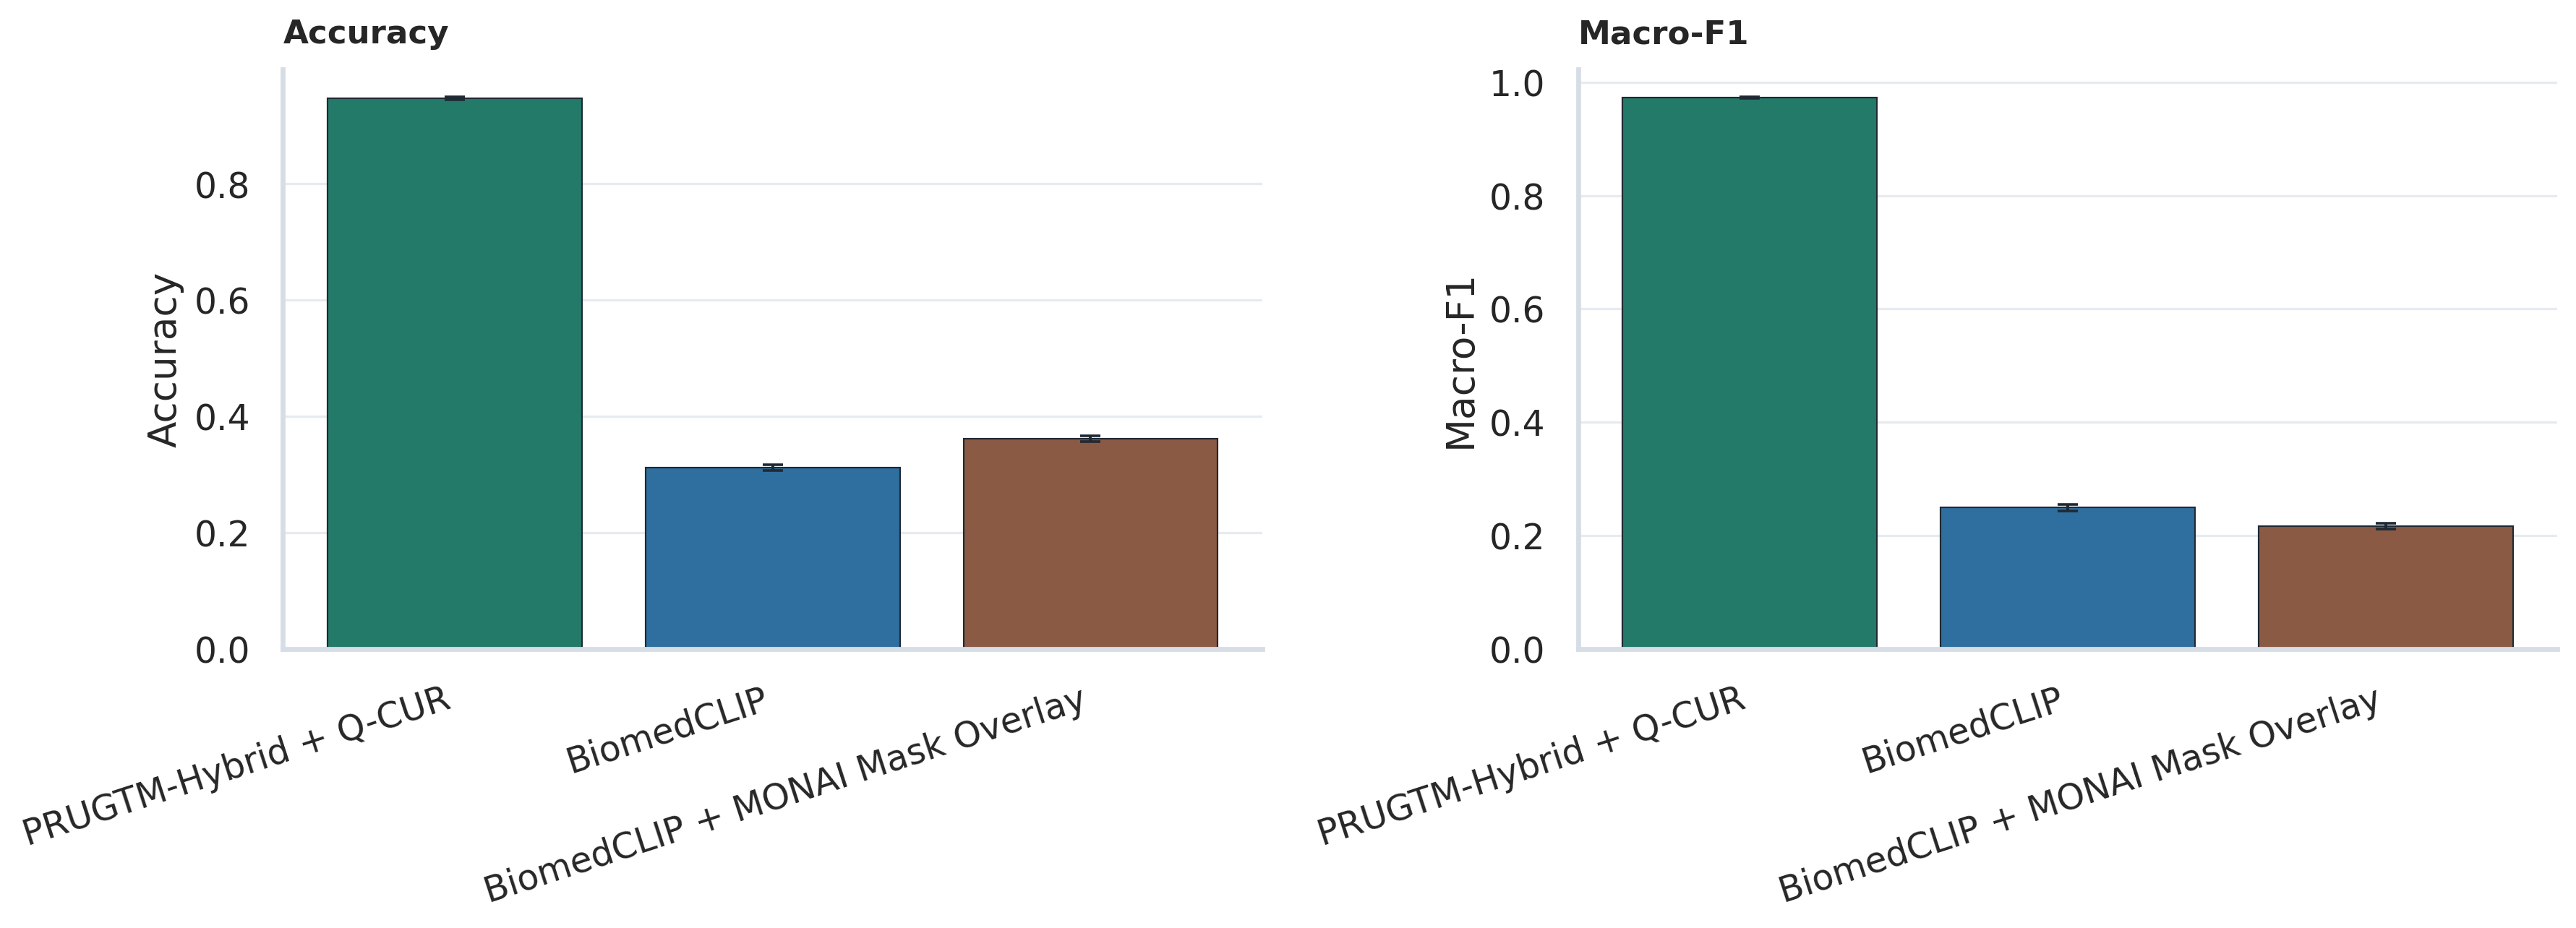

### Reliability Metrics with 95% CI

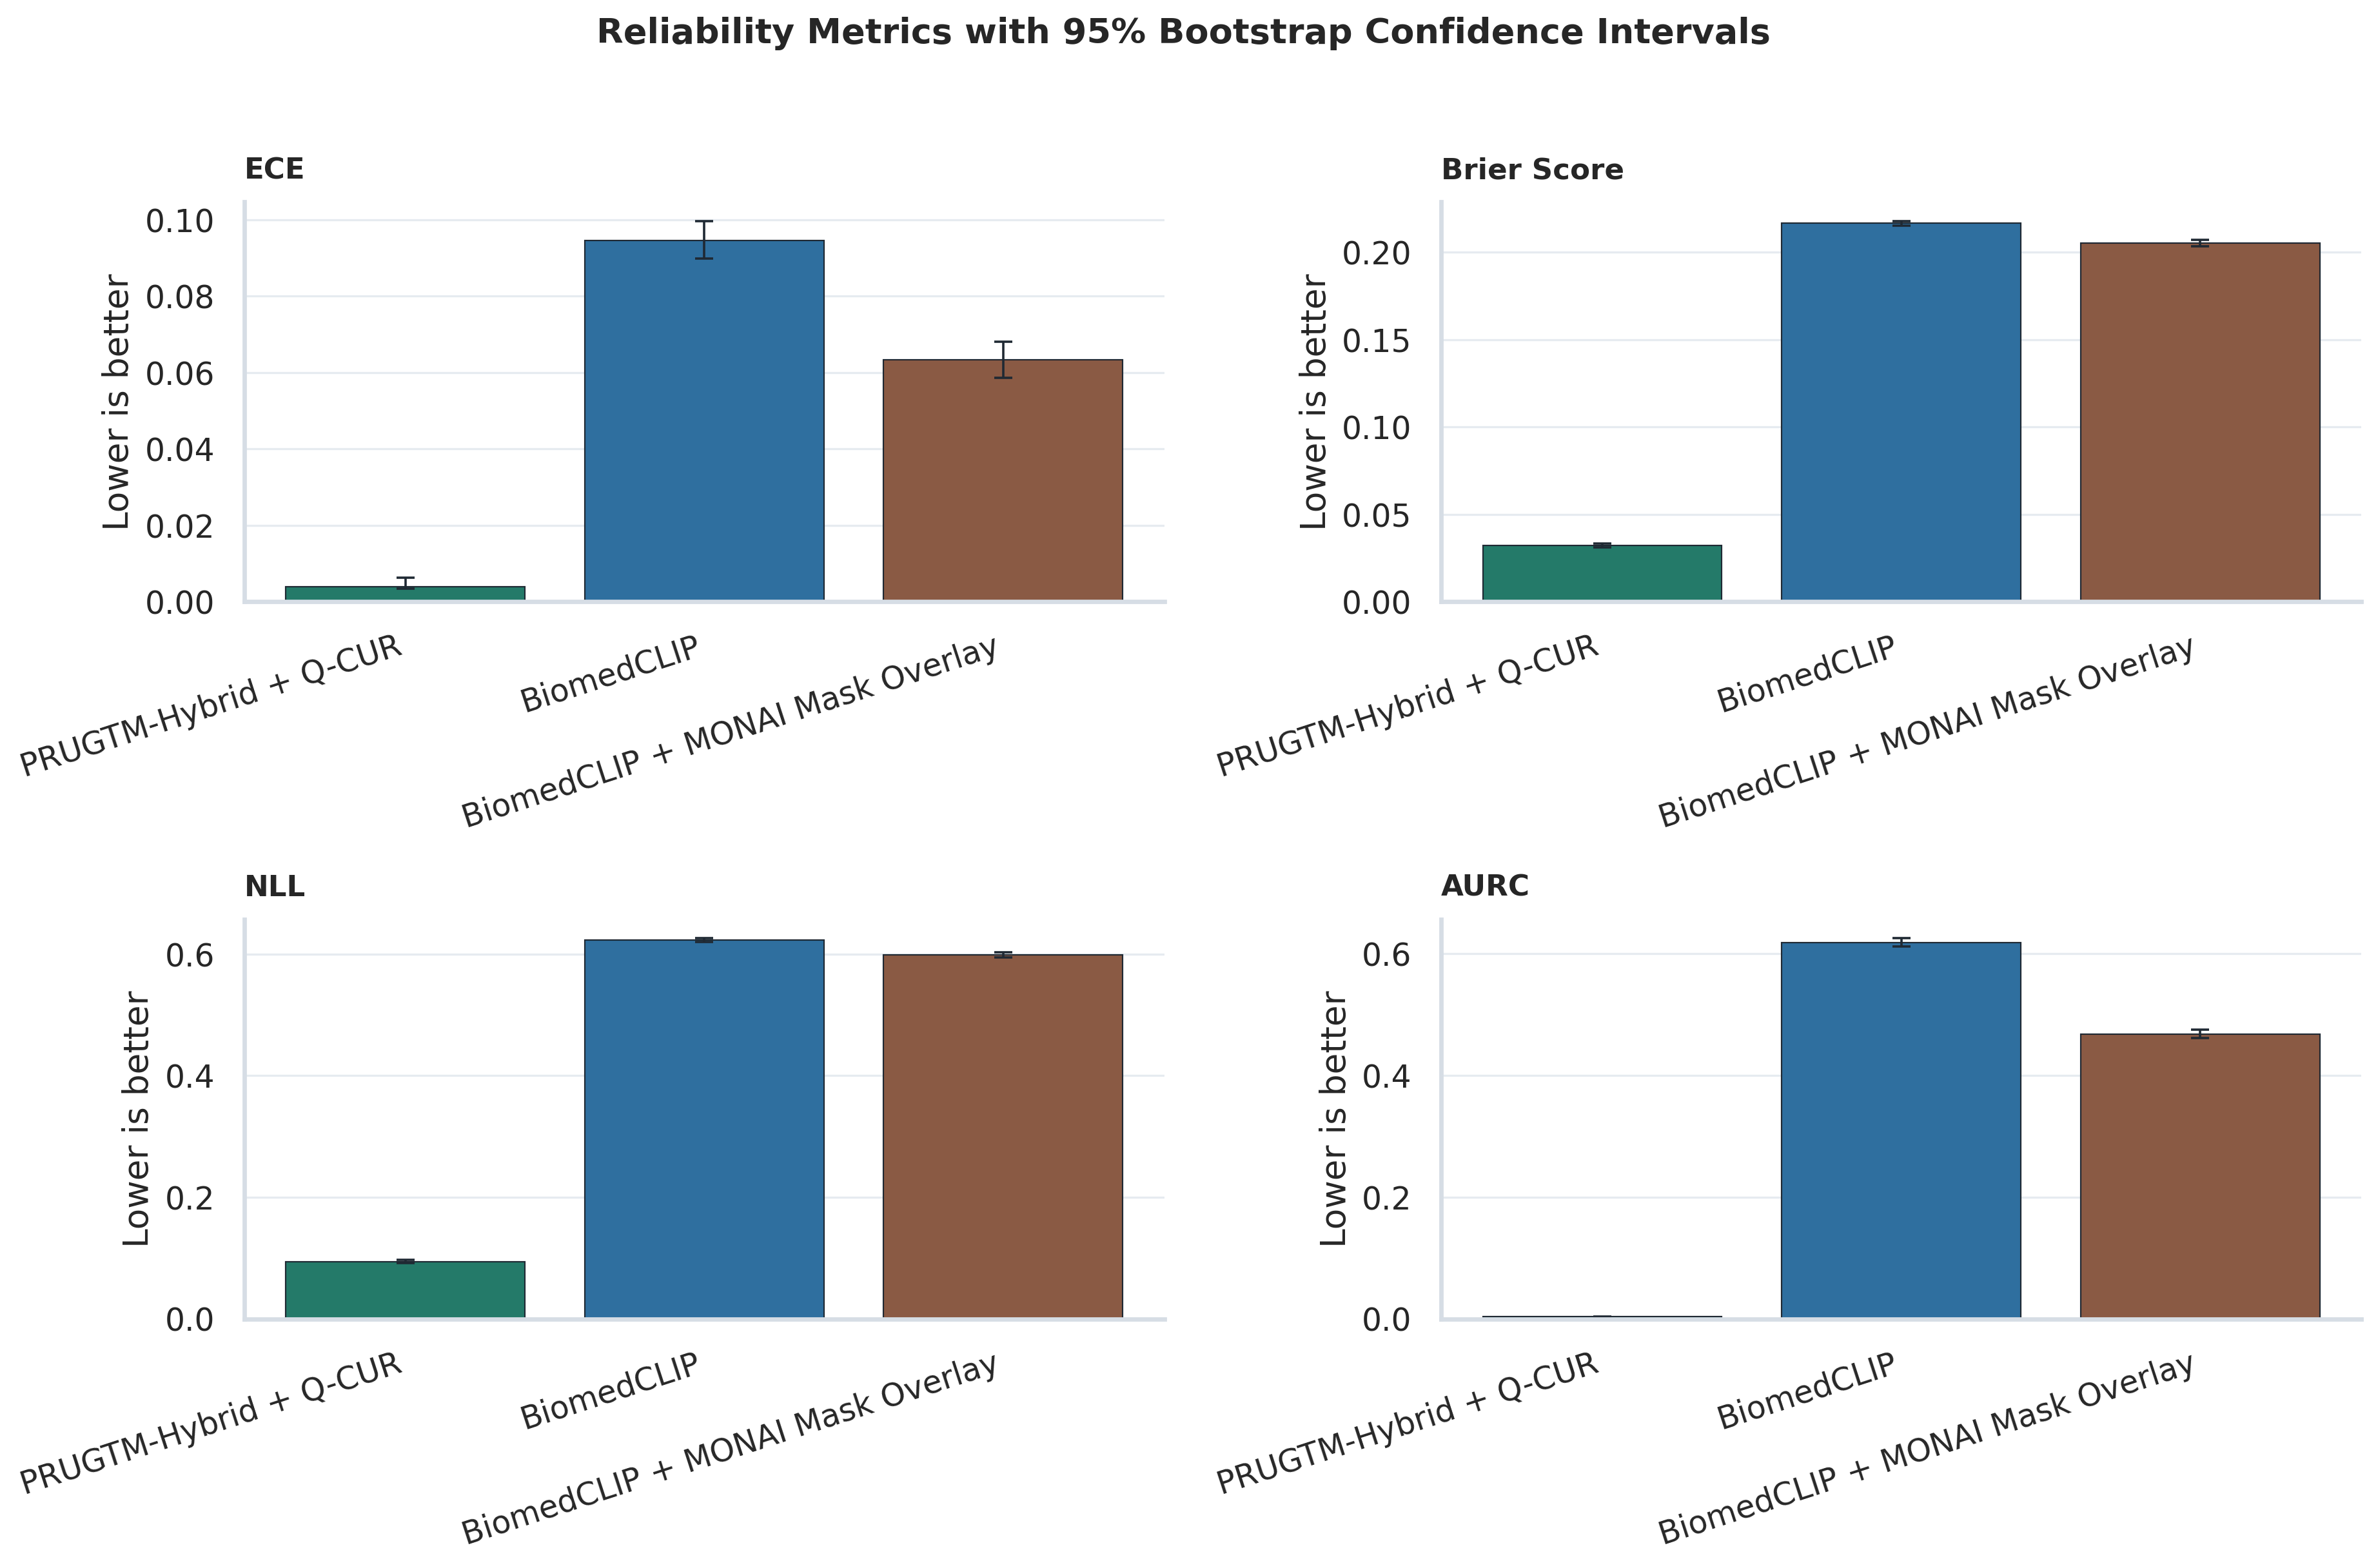

### Reliability Diagram

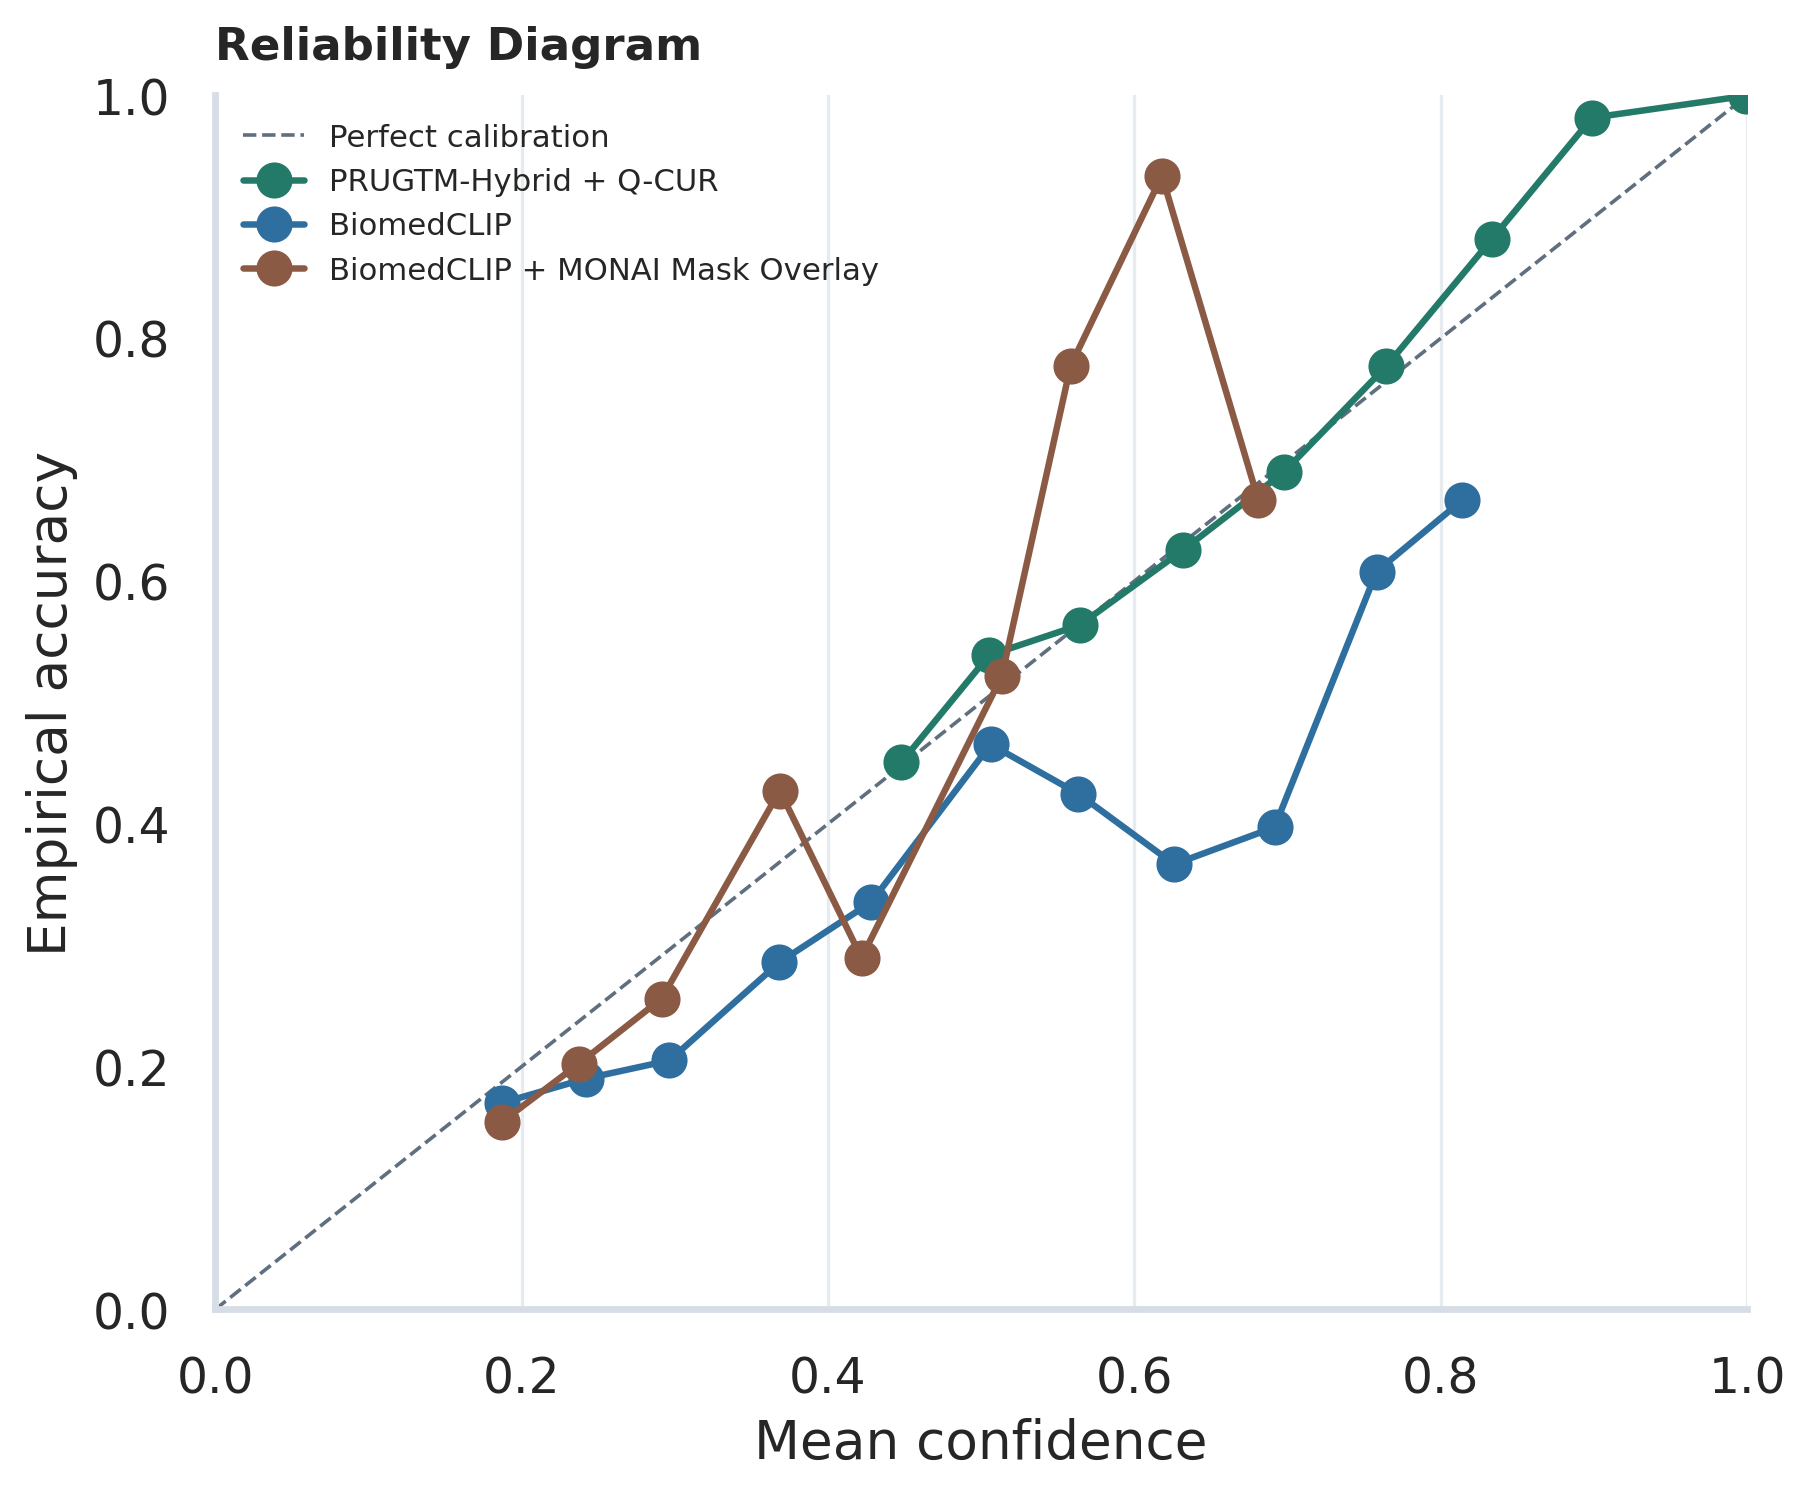

### Risk-Coverage Curve

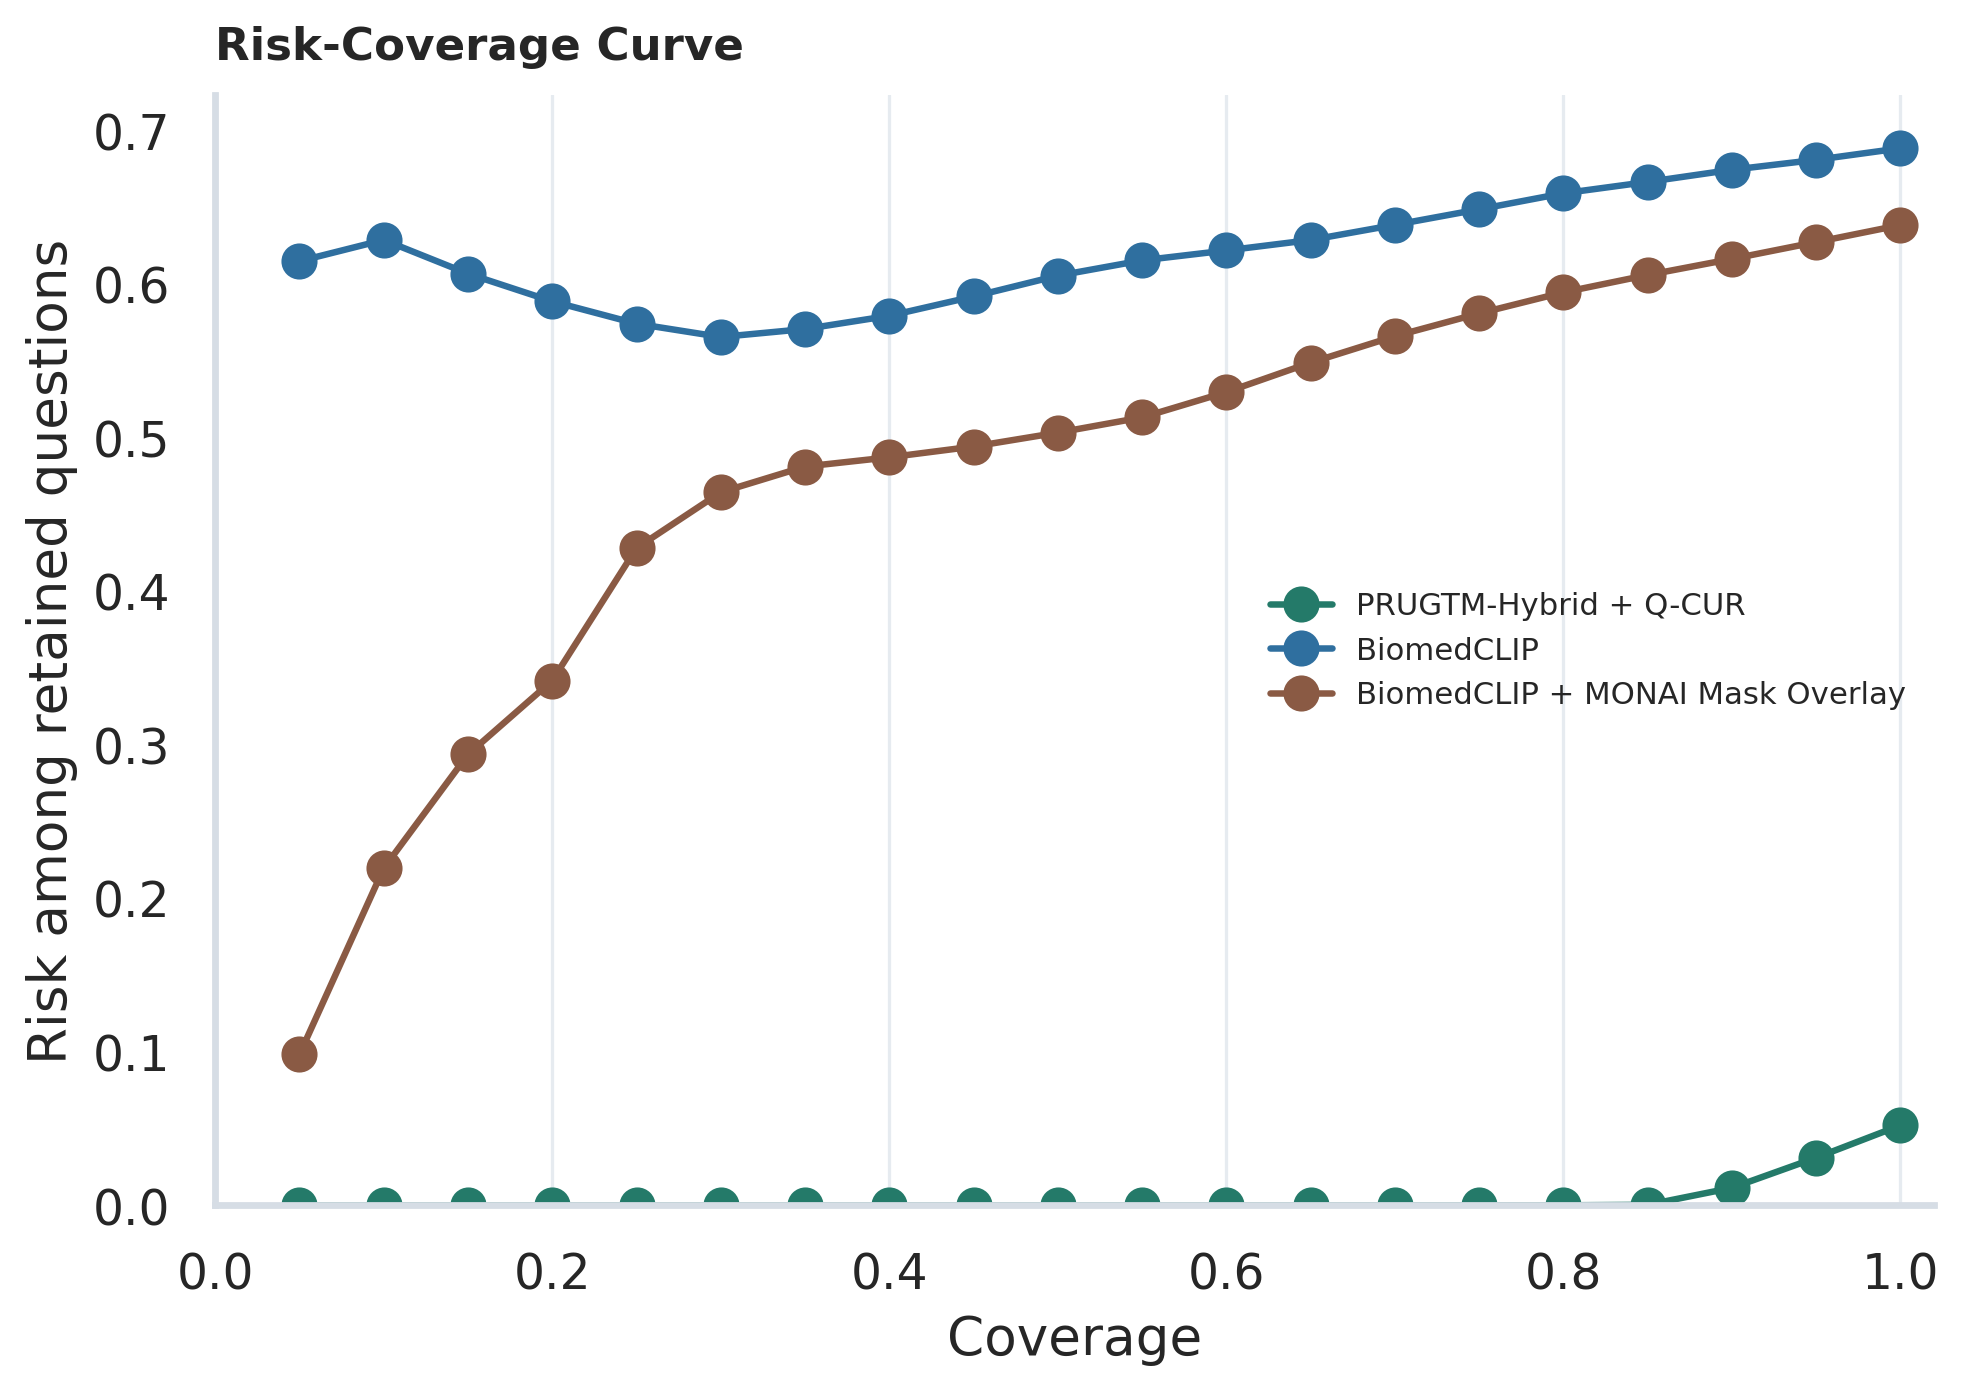

### Focused Slice Macro-F1

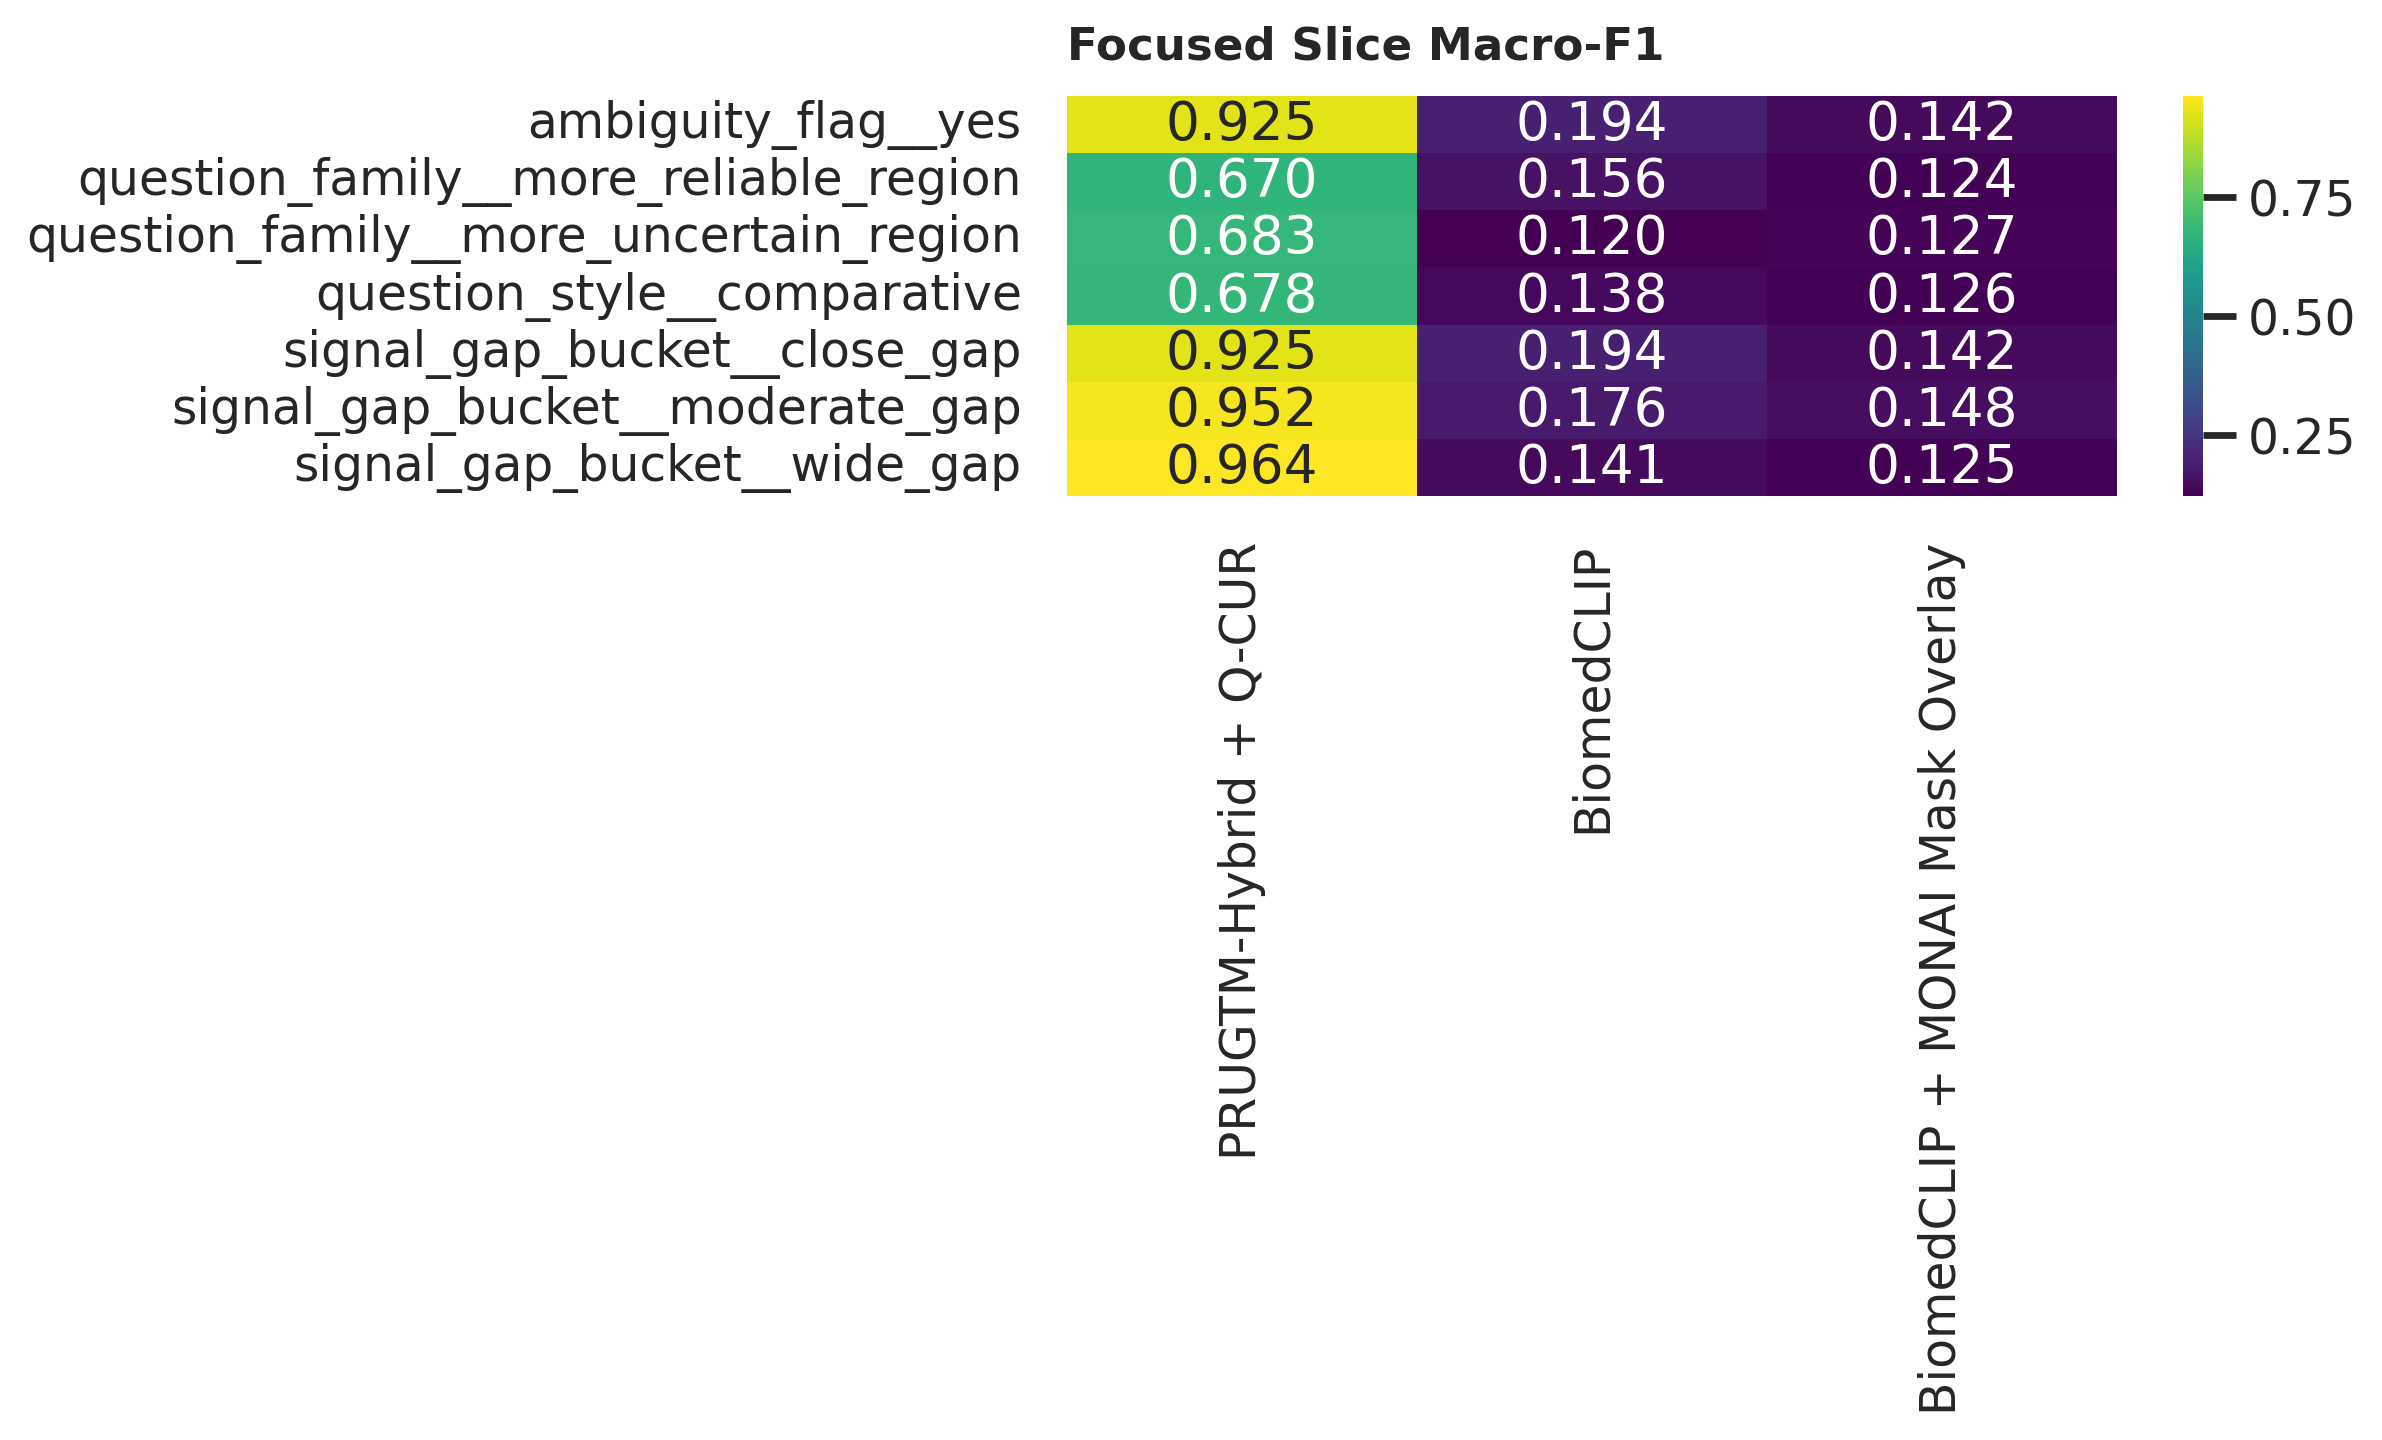

### Error Overlap

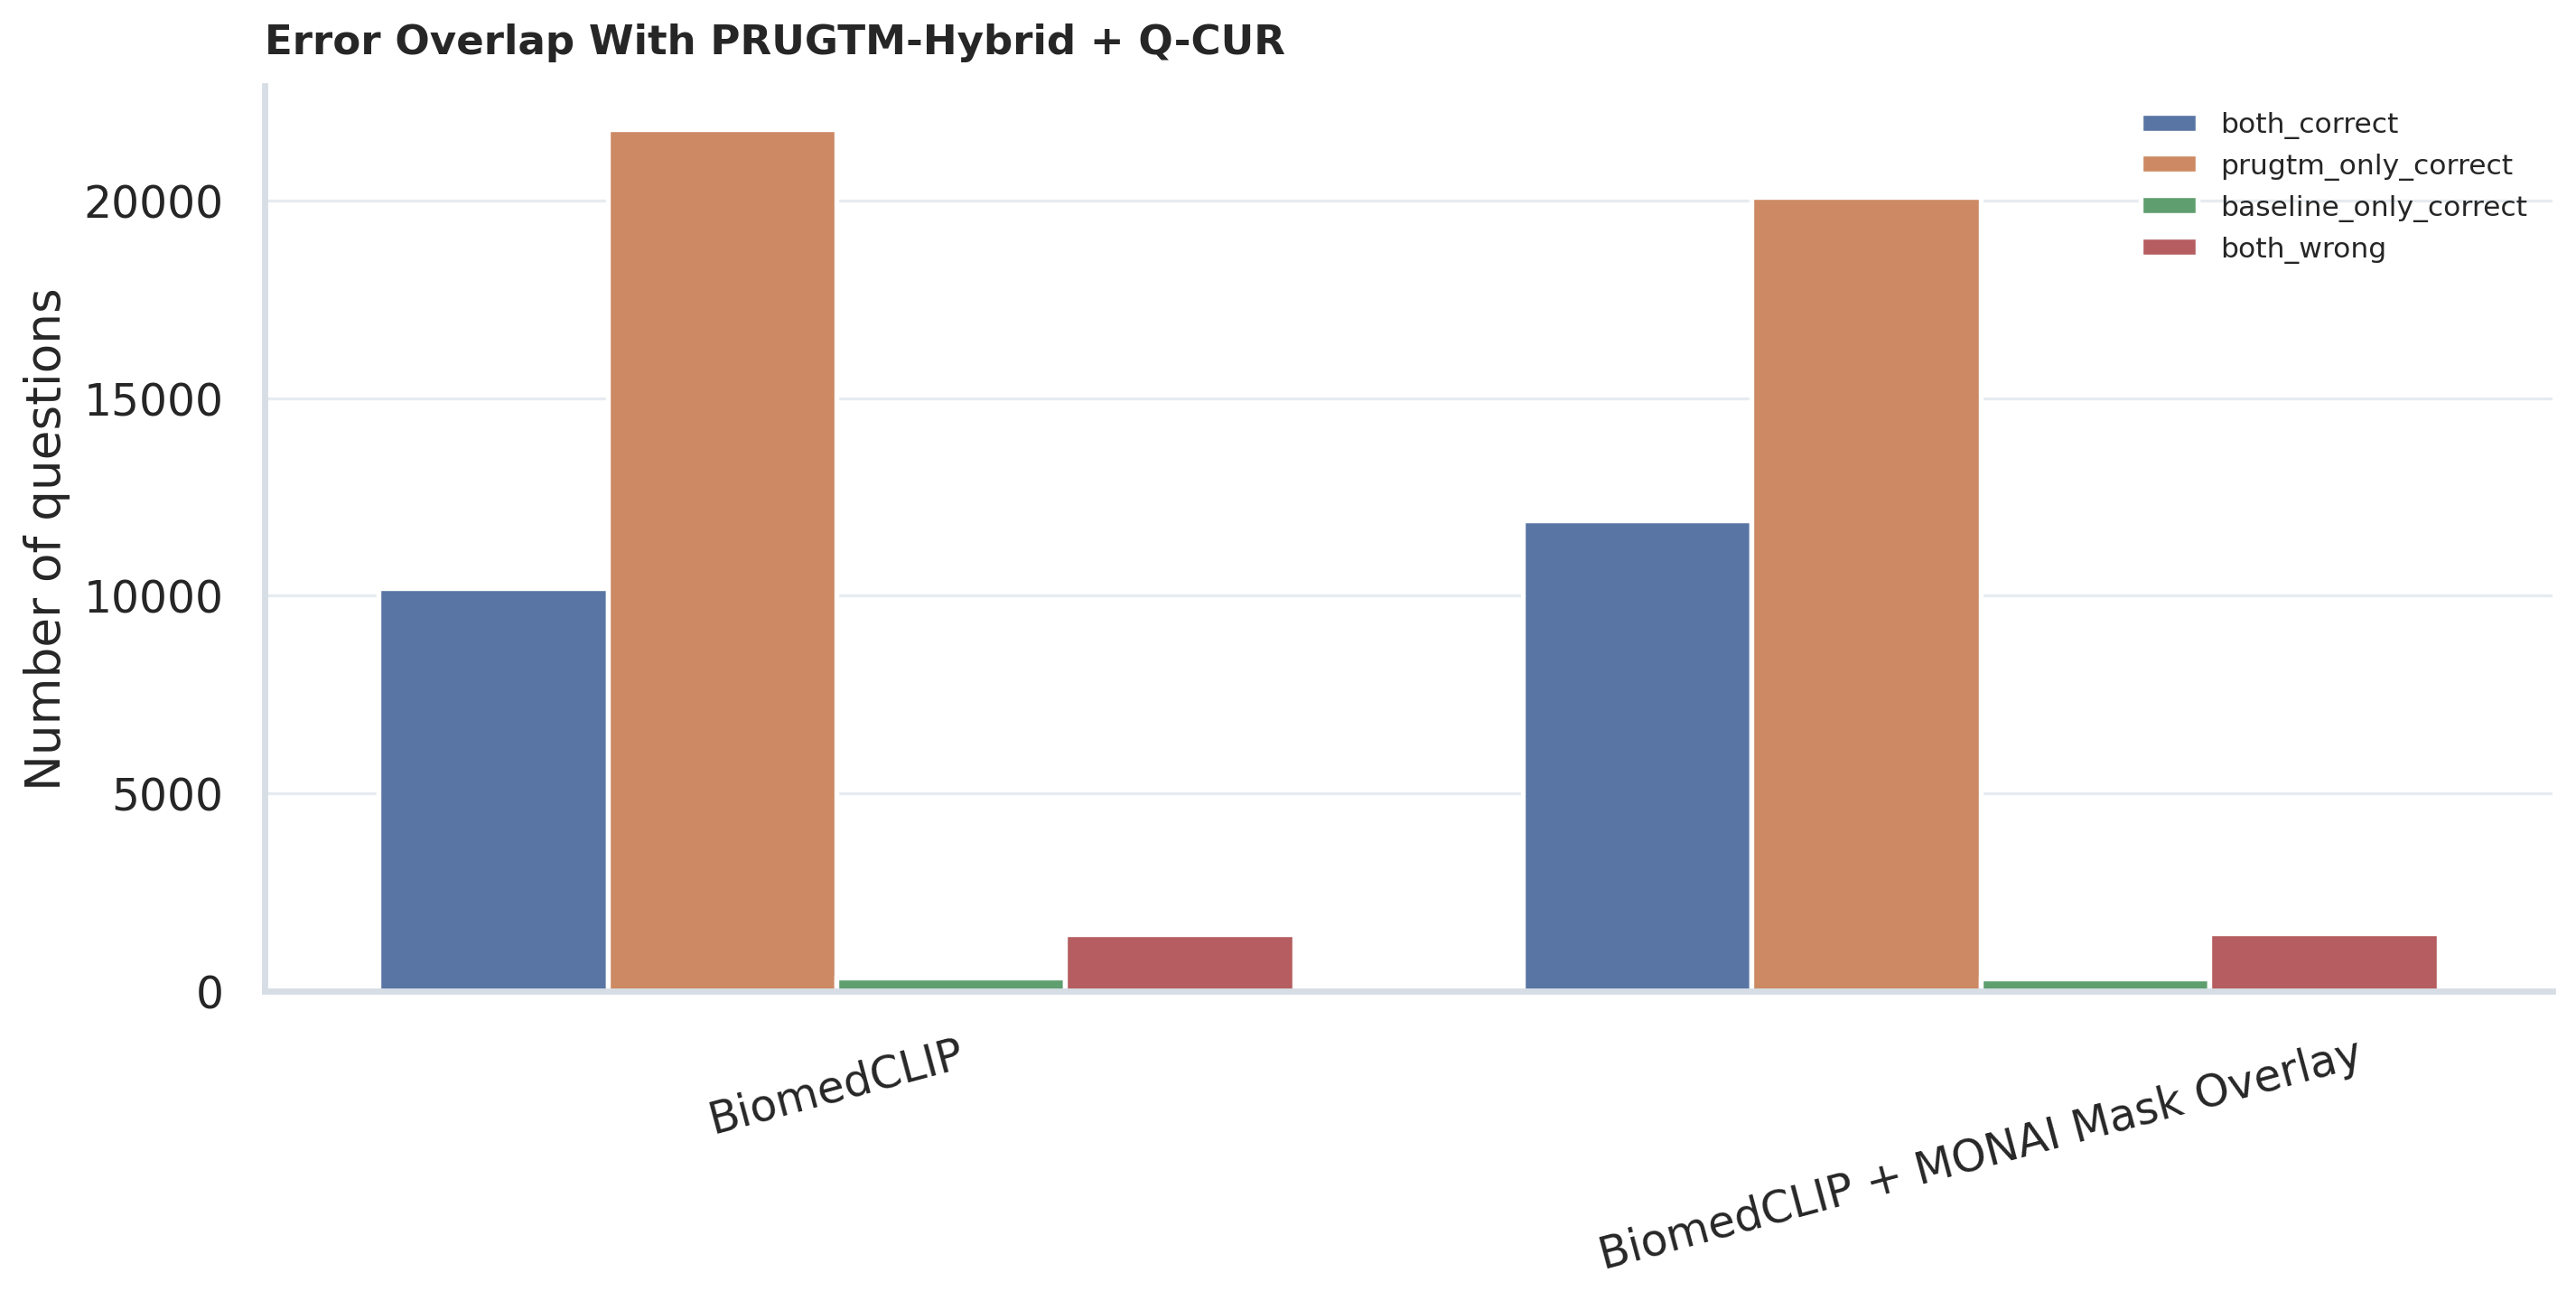

### BiomedCLIP Mask Overlay Effect

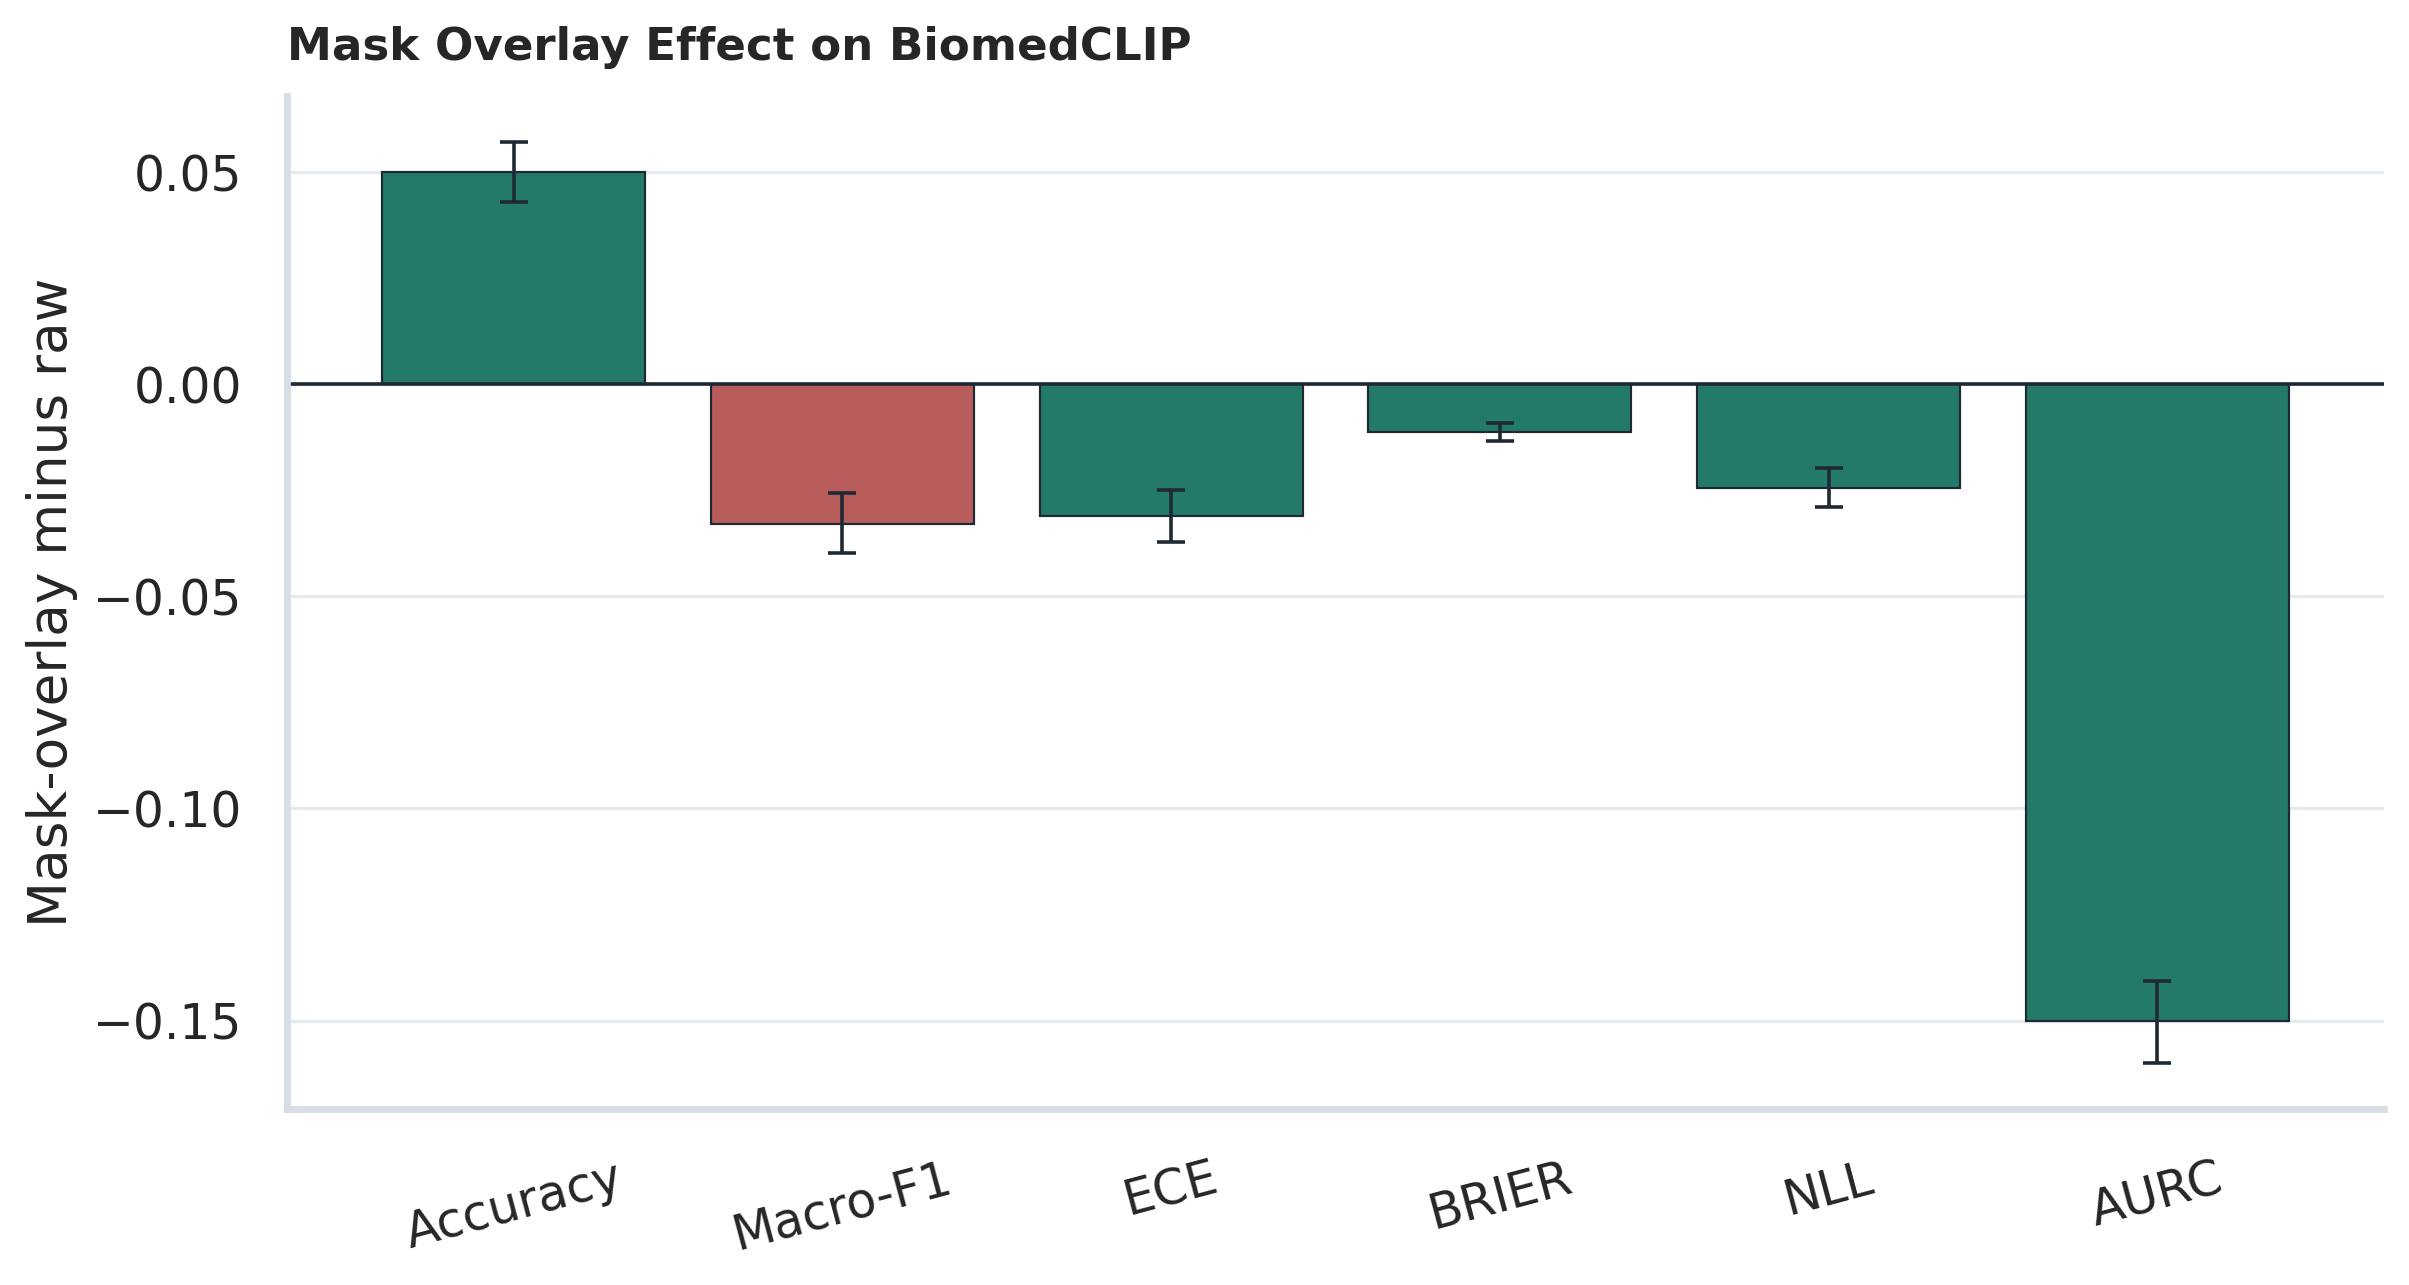

## Paper-Facing Interpretation

This dashboard summarizes whether explicit MONAI tumor-mask localization improves frozen BiomedCLIP, and whether localization alone closes the gap to the proposed PRUGTM-Hybrid + Q-CUR system.

**Important framing:** BiomedCLIP confidence is native candidate-softmax confidence. PRUGTM-Hybrid + Q-CUR confidence is validation-fitted calibrated confidence. Therefore, calibration results compare the proposed calibrated system against the native reliability behavior of frozen VLM baselines.

In [21]:
from IPython.display import display, Markdown, Image
import pandas as pd

display(Markdown("# Phase 05E Modern VLM Baseline Results"))
display(Markdown(
    f"**Run mode:** `{RUN_MODE}`  \n"
    f"**Primary comparison:** PRUGTM-Hybrid + Q-CUR vs available BiomedCLIP baselines"
))

def display_table(title, path, columns=None, sort_by=None, ascending=False, max_rows=20):
    display(Markdown(f"## {title}"))
    if not path.exists():
        display(Markdown(f"`Not generated: {path.name}`"))
        return None

    df = pd.read_csv(path)
    if columns is not None:
        columns = [col for col in columns if col in df.columns]
        df = df[columns]
    if sort_by is not None and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending)

    display(df.head(max_rows))
    return df

overall_show_df = display_table(
    "Answer Quality",
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_overall_answer_comparison.csv",
    columns=["model_label", "n", "valid_n", "error_n", "accuracy", "macro_f1", "weighted_f1"],
    sort_by="macro_f1",
    ascending=False,
)

calibration_show_df = display_table(
    "Reliability / Calibration",
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_calibration_comparison.csv",
    columns=[
        "model_label",
        "calibration_n",
        "ece",
        "brier",
        "nll",
        "aurc",
        "selective_acc_at_0.50",
        "selective_acc_at_0.80",
        "selective_acc_at_1.00",
    ],
    sort_by="ece",
    ascending=True,
)

paired_show_df = display_table(
    "Paired Statistical Differences",
    TABLES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_paired_bootstrap_differences.csv",
    columns=[
        "comparison",
        "baseline_label",
        "metric",
        "paired_n",
        "reference_observed",
        "baseline_observed",
        "difference_mean",
        "ci_low",
        "ci_high",
        "support",
    ],
    max_rows=50,
)

display(Markdown("## Visual Summary"))

dashboard_figure_paths = [
    ("Answer Quality with 95% CI", FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_answer_quality_with_ci.png"),
    ("Reliability Metrics with 95% CI", FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_reliability_metrics_with_ci.png"),
    ("Reliability Diagram", FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_reliability_diagram.png"),
    ("Risk-Coverage Curve", FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_risk_coverage_curve.png"),
    ("Focused Slice Macro-F1", FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_focused_slice_macro_f1_heatmap.png"),
    ("Error Overlap", FIGURES_DIR / f"phase05e_{RUN_MODE}_modern_vlm_error_overlap.png"),
    ("BiomedCLIP Mask Overlay Effect", FIGURES_DIR / f"phase05e_{RUN_MODE}_biomedclip_raw_vs_mask_overlay_paired_delta.png"),
]

for title, path in dashboard_figure_paths:
    if path.exists():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))

display(Markdown("## Paper-Facing Interpretation"))

if overall_show_df is not None and "model_label" in overall_show_df.columns:
    display(Markdown(
        "This dashboard summarizes whether explicit MONAI tumor-mask localization improves frozen BiomedCLIP, "
        "and whether localization alone closes the gap to the proposed PRUGTM-Hybrid + Q-CUR system."
    ))

display(Markdown(
    "**Important framing:** BiomedCLIP confidence is native candidate-softmax confidence. "
    "PRUGTM-Hybrid + Q-CUR confidence is validation-fitted calibrated confidence. "
    "Therefore, calibration results compare the proposed calibrated system against the native reliability behavior of frozen VLM baselines."
))
